# Water Segmentation Using Multispectral and Optical Data

## Project Overview

This project focuses on binary water segmentation from 12-channel multispectral and auxiliary remote-sensing data.

The main objective is to build a U-Net model from scratch that takes 12-channel image patches as input and predicts a binary water mask at pixel level.

The project covers:

- Dataset exploration and structure analysis
- Visualization of all 12 input bands
- RGB visualization
- Water-mask and class-distribution analysis
- Per-band normalization
- Multispectral feature engineering using MNDWI
- U-Net implementation from scratch
- Model training and evaluation
- Error analysis
- Comparison of different training strategies


In [2]:
print("Hello, Water Segmentation!")

Hello, Water Segmentation!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

In [5]:
os.listdir('/content/drive/MyDrive')

['Copy of handout-50-question-level-test-advanced-32-answers.pdf',
 'uldd.pdf',
 'Personal photo.jpg',
 'يسر حسن محمود ابراهيم.jpg',
 'يسر حسن محمود ابراهيم.pdf',
 'Graduation certificate - NID - Military status..pdf',
 'يسر حسن محمود.pdf',
 'pledge يسر حسن محمود.pdf',
 'Yossr Hassan',
 'Untitled document.gdoc',
 'myPhoto.jpg',
 "Yosrr's CV.pdf",
 'Yossr Hassan Mahmoud Ibrahim.pdf',
 'cv_new (1).pdf',
 'call_center_cv.pdf',
 'cv_new.pdf',
 'WhatsApp Image 2026-04-09 at 1.35.16 AM.jpeg',
 'WhatsApp Image 2026-04-09 at 1.35.16 AM (1).jpeg',
 "Bachelor's Thesis.pdf",
 '89e5be88-a534-430f-a2a7-7aaa13e1036b.csv',
 '89e5be88-a534-430f-a2a7-7aaa13e1036b.gsheet',
 'Yossr_Hassan_CV.pdf',
 'Colab Notebooks',
 'EyeDiseaseDataset.zip',
 'Untitled',
 'satalite data']

In [6]:
os.listdir('/content/drive/MyDrive/satalite data')

['data']

In [7]:
data_path = '/content/drive/MyDrive/satalite data'

print("Contents of satalite data:")
print(os.listdir(data_path))

print("\nImages:")
print(os.listdir(data_path + '/data/images')[:10])

print("\nLabels:")
print(os.listdir(data_path + '/data/labels')[:10])

Contents of satalite data:
['data']

Images:
['0.tif', '1.tif', '3.tif', '8.tif', '5.tif', '7.tif', '9.tif', '6.tif', '4.tif', '10.tif']

Labels:
['45.png', '150.png', '102.png', '249.png', '118.png', '21.png', '93.png', '217.png', '41.png', '66.png']


In [8]:
import tifffile
import numpy as np

images_path = data_path + '/data/images'
labels_path = data_path + '/data/labels'

image_files = os.listdir(images_path)
label_files = os.listdir(labels_path)

print("Number of images:", len(image_files))
print("Number of labels:", len(label_files))

# Read one TIFF image
sample_image_path = os.path.join(images_path, image_files[0])
sample_image = tifffile.imread(sample_image_path)

print("\nSample image:", image_files[0])
print("Image shape:", sample_image.shape)
print("Image dtype:", sample_image.dtype)
print("Min value:", sample_image.min())
print("Max value:", sample_image.max())

Number of images: 306
Number of labels: 456

Sample image: 0.tif
Image shape: (128, 128, 12)
Image dtype: int16
Min value: -28
Max value: 4975


In [9]:
from PIL import Image

# Read the first 5 labels
for filename in label_files[:5]:
    label_path = os.path.join(labels_path, filename)
    label = np.array(Image.open(label_path))

    print(
        filename,
        "| shape:", label.shape,
        "| dtype:", label.dtype,
        "| unique values:", np.unique(label)
    )

45.png | shape: (128, 128) | dtype: uint8 | unique values: [0 1]
150.png | shape: (128, 128) | dtype: uint8 | unique values: [0 1]
102.png | shape: (128, 128) | dtype: uint8 | unique values: [0 1]
249.png | shape: (128, 128) | dtype: uint8 | unique values: [0 1]
118.png | shape: (128, 128) | dtype: uint8 | unique values: [0 1]


In [10]:
print("Image filenames:")
print(sorted(image_files, key=lambda x: int(os.path.splitext(x)[0]))[:30])

print("\nLabel filenames:")
print(sorted(label_files, key=lambda x: int(os.path.splitext(x)[0]))[:30])

Image filenames:
['0.tif', '1.tif', '2.tif', '3.tif', '4.tif', '5.tif', '6.tif', '7.tif', '8.tif', '9.tif', '10.tif', '11.tif', '12.tif', '13.tif', '14.tif', '15.tif', '16.tif', '17.tif', '18.tif', '19.tif', '20.tif', '21.tif', '22.tif', '23.tif', '24.tif', '25.tif', '26.tif', '27.tif', '28.tif', '29.tif']

Label filenames:
['0.png', '1.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png', '10.png', '11.png', '12.png', '13.png', '14.png', '15.png', '16.png', '17.png', '18.png', '19.png', '20.png', '21.png', '22.png', '23.png', '24.png', '25.png', '26.png', '27.png', '28.png', '29.png']


In [11]:
image_ids = {
    int(os.path.splitext(f)[0])
    for f in image_files
    if f.endswith('.tif')
}

label_ids = {
    int(os.path.splitext(f)[0])
    for f in label_files
    if f.endswith('.png')
}

labels_without_images = sorted(label_ids - image_ids)
images_without_labels = sorted(image_ids - label_ids)

print("Images:", len(image_ids))
print("Labels:", len(label_ids))

print("\nLabels without matching images:")
print(labels_without_images)

print("\nImages without matching labels:")
print(images_without_labels)

Images: 306
Labels: 455

Labels without matching images:
[374, 819, 873, 1226, 1760, 1842, 2215, 2216, 3211, 3530, 3868, 3927, 4177, 4300, 4655, 4715, 4812, 4964, 5191, 5275, 5343, 5451, 5619, 5745, 6248, 6317, 6486, 6622, 6918, 7146, 7323, 7465, 7552, 7692, 7761, 8476, 9202, 10189, 10244, 10420, 10759, 11116, 11278, 11344, 11549, 11797, 12286, 12495, 12754, 13234, 13556, 13839, 14034, 14135, 14684, 15233, 16229, 19293, 20283, 21254, 23251, 24111, 25172, 26274, 27290, 29186, 30143, 31196, 33134, 34239, 36240, 37118, 40277, 42281, 43149, 44191, 45158, 50263, 52160, 55219, 58114, 59132, 60245, 61206, 62187, 65203, 67156, 68180, 70268, 71120, 72205, 78246, 79161, 80124, 82100, 83131, 85117, 86288, 87182, 88157, 89228, 90303, 91102, 92272, 93217, 94119, 95221, 96154, 97130, 98253, 99170, 100184, 102179, 103225, 105148, 106267, 108236, 109223, 110287, 111121, 114220, 116250, 118125, 119222, 120305, 121142, 122257, 123145, 125201, 126110, 128294, 129177, 130256, 131185, 132126, 133224, 13415

In [12]:
import pandas as pd

# Calculate statistics for each of the 12 channels
band_stats = []

for band in range(12):
    values = []

    for filename in sorted(image_files, key=lambda x: int(os.path.splitext(x)[0])):
        image = tifffile.imread(os.path.join(images_path, filename))
        values.append(image[:, :, band].ravel())

    values = np.concatenate(values)

    band_stats.append({
        "Band": band + 1,
        "Min": values.min(),
        "Max": values.max(),
        "Mean": values.mean(),
        "Std": values.std()
    })

band_stats_df = pd.DataFrame(band_stats)

print(band_stats_df.to_string(index=False))

 Band   Min   Max        Mean         Std
    1 -1393  6568  396.467673  270.066593
    2 -1169  9659  494.621029  325.979197
    3  -722 11368  822.319785  418.121630
    4  -684 12041  973.674961  586.702975
    5  -412 15841 2090.110996 1055.984607
    6  -335 15252 1964.050569 1191.422266
    7  -258 14647 1351.273953  961.762588
    8    64   255  102.739630   48.804015
    9 -9999  4245  141.803906 1364.981121
   10     8  4287  300.741363  496.038807
   11    10   100   35.102533   20.184525
   12     0   111    9.753326   27.758307


In [13]:
sample_image_path = os.path.join(images_path, "0.tif")

with tifffile.TiffFile(sample_image_path) as tif:
    print(tif.pages[0].tags)

TiffTag 256 ImageWidth @394264 SHORT @394272 = 128
TiffTag 257 ImageLength @394276 SHORT @394284 = 128
TiffTag 258 BitsPerSample @394288 SHORT[12] @394412 = (16, 16, 16, 16, 16, 16,
TiffTag 259 Compression @394300 SHORT @394308 = NONE
TiffTag 262 PhotometricInterpretation @394312 SHORT @394320 = MINISBLACK
TiffTag 273 StripOffsets @394324 LONG[64] @394564 = (1046, 7190, 13334, 19478,
TiffTag 277 SamplesPerPixel @394336 SHORT @394344 = 12
TiffTag 278 RowsPerStrip @394348 SHORT @394356 = 2
TiffTag 279 StripByteCounts @394360 SHORT[64] @394436 = (6144, 6144, 6144, 6144
TiffTag 284 PlanarConfiguration @394372 SHORT @394380 = CONTIG
TiffTag 338 ExtraSamples @394384 SHORT[11] @394820 = ('UNSPECIFIED', 'UNSPECIFI
TiffTag 339 SampleFormat @394396 SHORT[12] @394842 = ('INT', 'INT', 'INT', 'INT


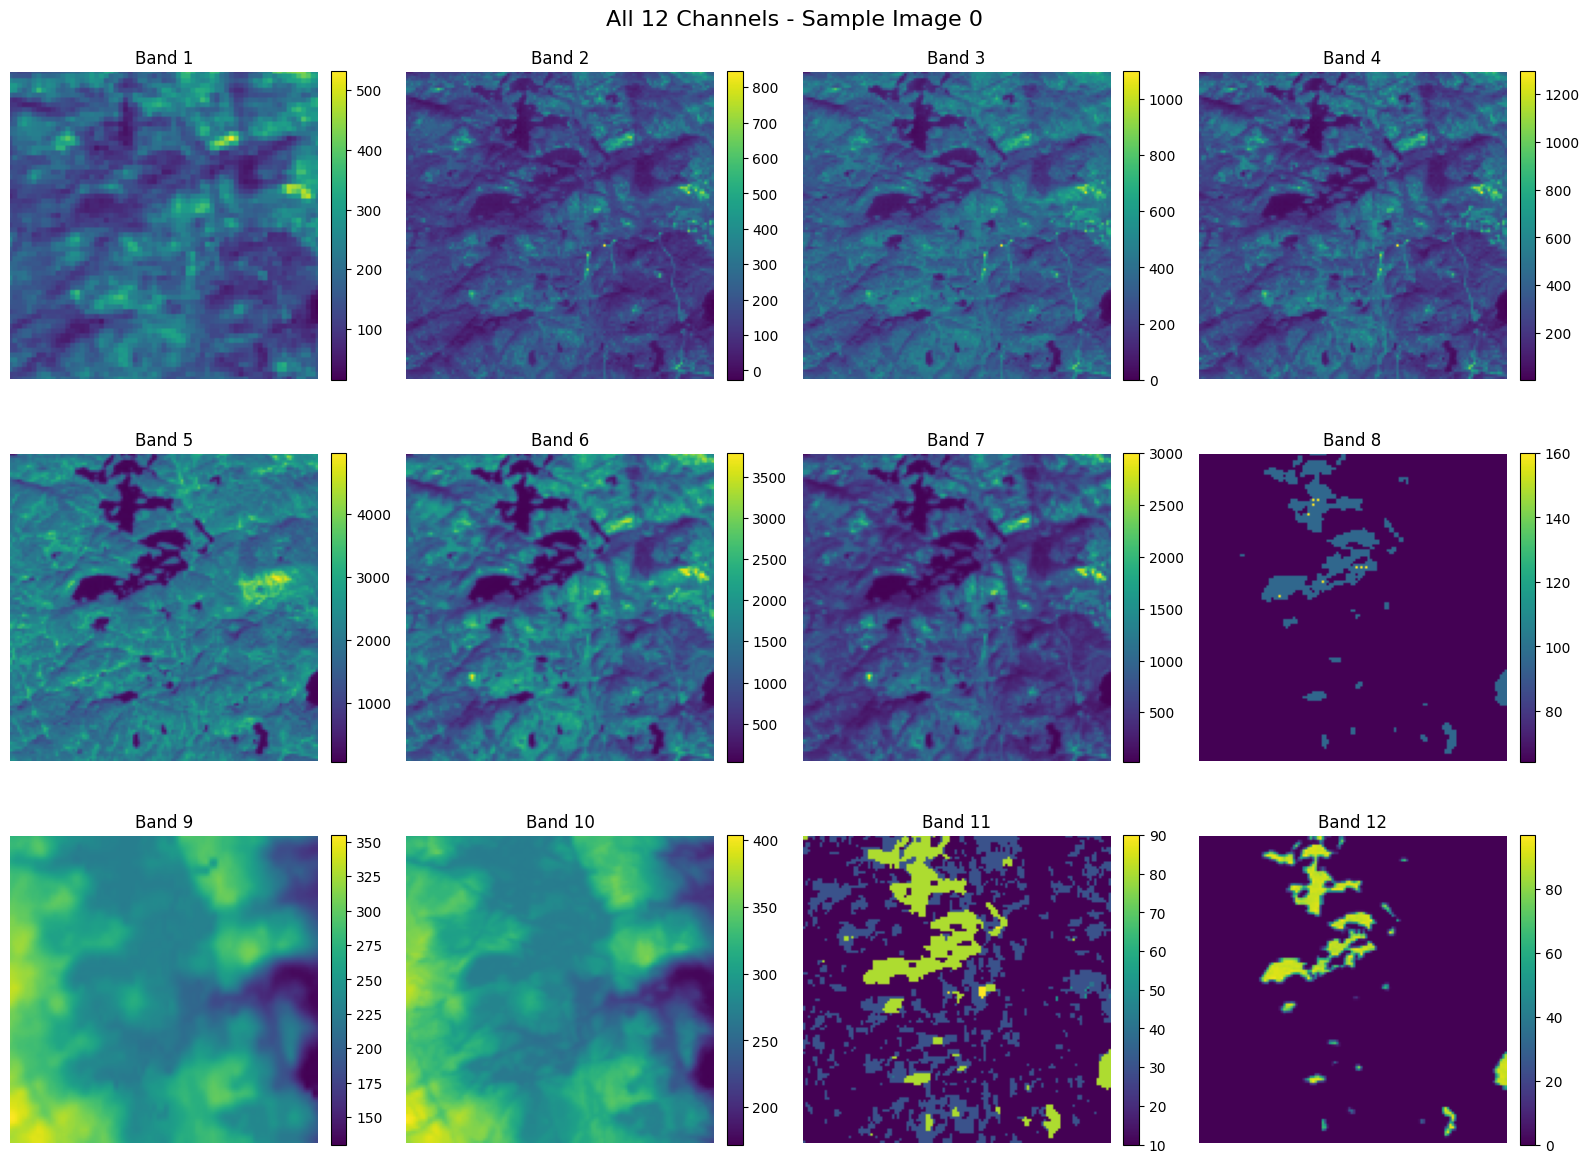

In [14]:
import matplotlib.pyplot as plt

# Load one sample image
sample = tifffile.imread(os.path.join(images_path, "0.tif"))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(sample[:, :, i])
    ax.set_title(f"Band {i+1}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("All 12 Channels - Sample Image 0", fontsize=16)
plt.tight_layout()
plt.show()

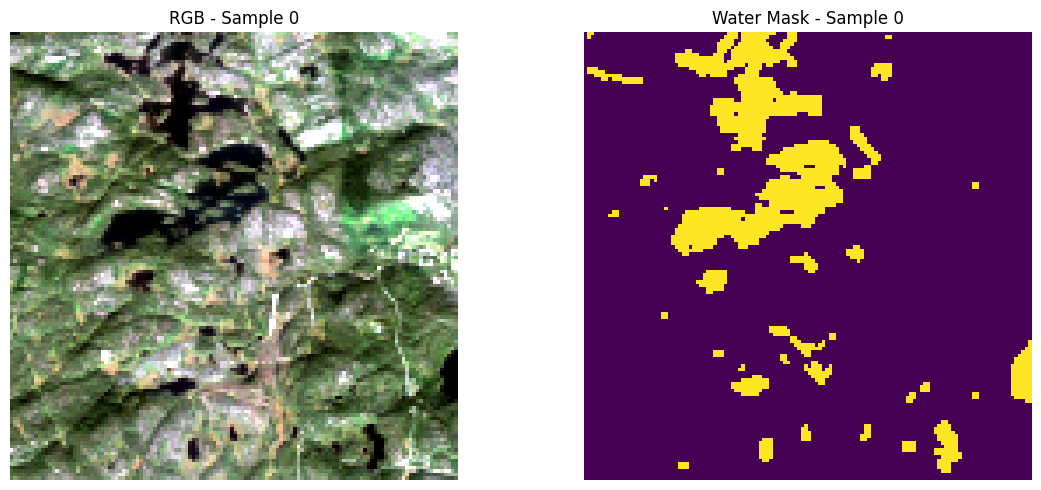

In [15]:
# Load image and matching mask
sample = tifffile.imread(os.path.join(images_path, "0.tif"))
mask = np.array(Image.open(os.path.join(labels_path, "0.png")))

# RGB = Red, Green, Blue
rgb = sample[:, :, [3, 2, 1]].astype(np.float32)

# Contrast stretching for visualization only
rgb_min = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
rgb_max = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)

rgb = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8)
rgb = np.clip(rgb, 0, 1)

# Plot RGB and mask
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(rgb)
axes[0].set_title("RGB - Sample 0")
axes[0].axis("off")

axes[1].imshow(mask)
axes[1].set_title("Water Mask - Sample 0")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
total_water = 0
total_non_water = 0

for image_id in sorted(image_ids):
    label_path = os.path.join(labels_path, f"{image_id}.png")
    mask = np.array(Image.open(label_path))

    total_water += np.sum(mask == 1)
    total_non_water += np.sum(mask == 0)

total_pixels = total_water + total_non_water

water_percentage = (total_water / total_pixels) * 100
non_water_percentage = (total_non_water / total_pixels) * 100

print("Total pixels:", total_pixels)
print("Water pixels:", total_water)
print("Non-water pixels:", total_non_water)
print(f"Water percentage: {water_percentage:.2f}%")
print(f"Non-water percentage: {non_water_percentage:.2f}%")

Total pixels: 5013504
Water pixels: 1302272
Non-water pixels: 3711232
Water percentage: 25.98%
Non-water percentage: 74.02%


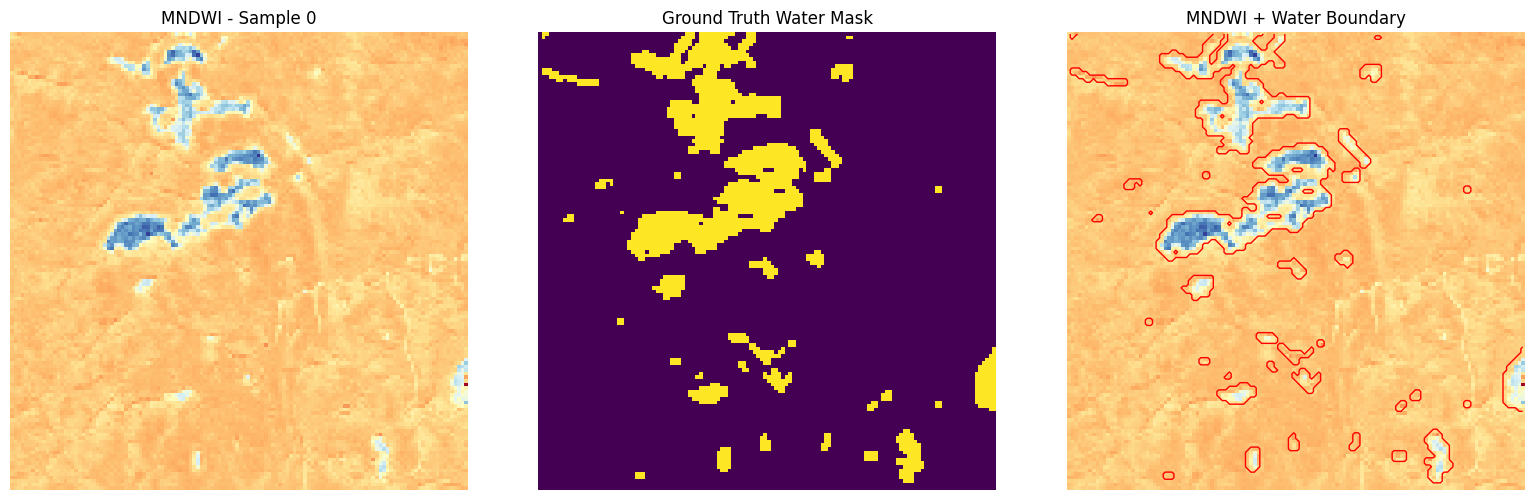

In [17]:
# Load the spectral bands
sample = tifffile.imread(os.path.join(images_path, "0.tif")).astype(np.float32)

green = sample[:, :, 2]   # Channel 3
swir1 = sample[:, :, 5]   # Channel 6

# Calculate MNDWI
mndwi = (green - swir1) / (green + swir1 + 1e-8)

# Load ground-truth mask
mask = np.array(Image.open(os.path.join(labels_path, "0.png")))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(mndwi, cmap="RdYlBu")
axes[0].set_title("MNDWI - Sample 0")
axes[0].axis("off")

axes[1].imshow(mask)
axes[1].set_title("Ground Truth Water Mask")
axes[1].axis("off")

axes[2].imshow(mndwi, cmap="RdYlBu")
axes[2].contour(mask, levels=[0.5], colors="red", linewidths=1)
axes[2].set_title("MNDWI + Water Boundary")
axes[2].axis("off")

plt.tight_layout()
plt.show()

NDWI shape: (128, 128)
NDWI min: -1.0701754
NDWI max: 0.24324325
NDWI mean: -0.69211125
NDWI std: 0.11579301


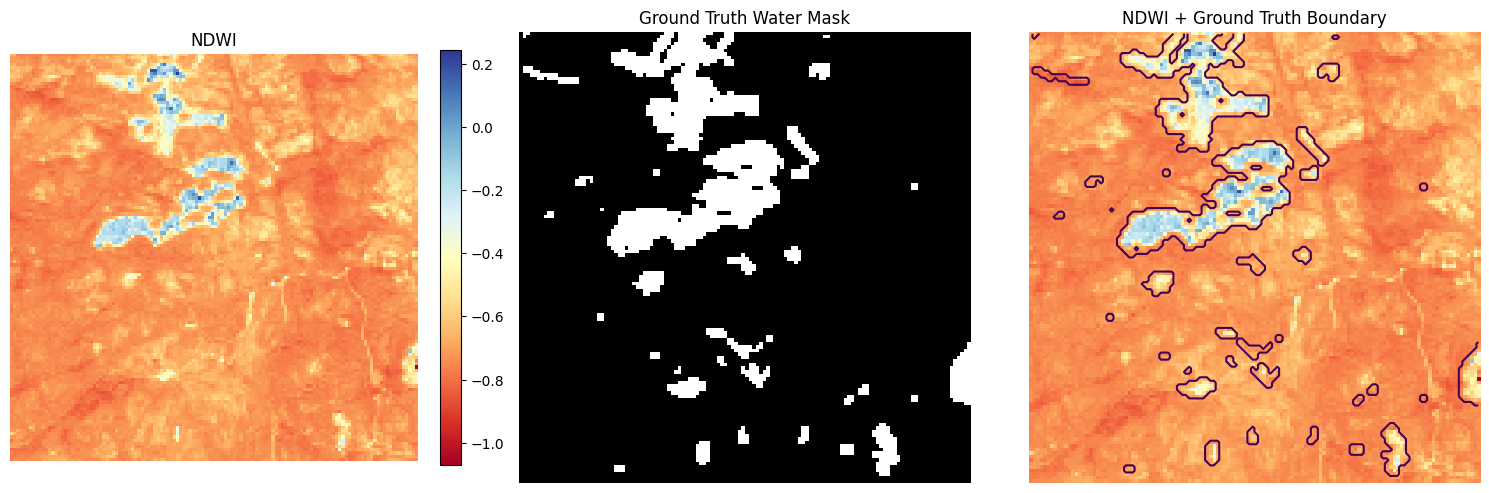

In [18]:
# =========================
# NDWI Visualization
# =========================

# Read sample image
sample = tifffile.imread(
    os.path.join(images_path, "0.tif")
).astype(np.float32)

# Select bands
green = sample[:, :, 2]   # Band 3: Green
nir   = sample[:, :, 4]   # Band 5: NIR

# Calculate NDWI
ndwi = (green - nir) / (green + nir + 1e-8)

# Read ground-truth mask
mask = np.array(
    Image.open(os.path.join(labels_path, "0.png"))
)

# Print NDWI statistics
print("NDWI shape:", ndwi.shape)
print("NDWI min:", np.nanmin(ndwi))
print("NDWI max:", np.nanmax(ndwi))
print("NDWI mean:", np.nanmean(ndwi))
print("NDWI std:", np.nanstd(ndwi))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# NDWI
im1 = axes[0].imshow(ndwi, cmap="RdYlBu")
axes[0].set_title("NDWI")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Ground truth
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Ground Truth Water Mask")
axes[1].axis("off")

# NDWI + ground truth boundary
axes[2].imshow(ndwi, cmap="RdYlBu")
axes[2].contour(mask, levels=[0.5])
axes[2].set_title("NDWI + Ground Truth Boundary")
axes[2].axis("off")

plt.tight_layout()
plt.show()

===== NDWI =====
Water:
  Mean: -0.49600798
  Std : 0.22043951
Non-water:
  Mean: -0.71809655
  Std : 0.05453981

===== MNDWI =====
Water:
  Mean: -0.36000177
  Std : 0.2600682
Non-water:
  Mean: -0.596069
  Std : 0.038704876


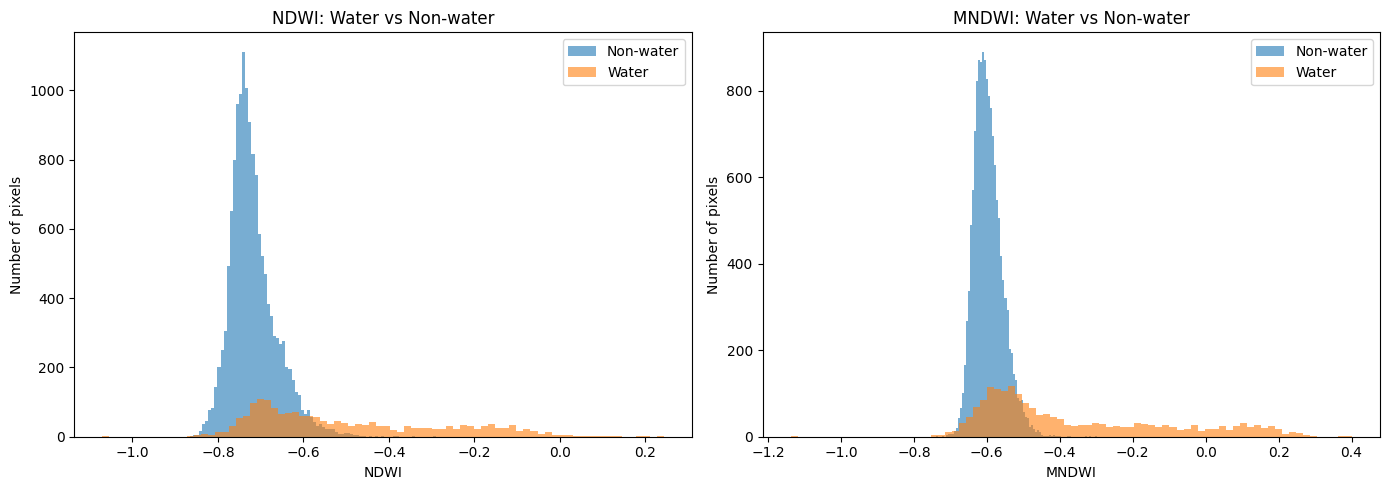

In [19]:
# ==========================================
# Compare NDWI and MNDWI for Water vs Non-Water
# ==========================================

# We already have:
# sample
# mask
# ndwi

# Calculate MNDWI
green = sample[:, :, 2]
swir1 = sample[:, :, 5]

mndwi = (green - swir1) / (green + swir1 + 1e-8)

# Create boolean masks
water_pixels = mask == 1
non_water_pixels = mask == 0

# Extract values
ndwi_water = ndwi[water_pixels]
ndwi_non_water = ndwi[non_water_pixels]

mndwi_water = mndwi[water_pixels]
mndwi_non_water = mndwi[non_water_pixels]

# Print statistics
print("===== NDWI =====")
print("Water:")
print("  Mean:", np.mean(ndwi_water))
print("  Std :", np.std(ndwi_water))

print("Non-water:")
print("  Mean:", np.mean(ndwi_non_water))
print("  Std :", np.std(ndwi_non_water))

print("\n===== MNDWI =====")
print("Water:")
print("  Mean:", np.mean(mndwi_water))
print("  Std :", np.std(mndwi_water))

print("Non-water:")
print("  Mean:", np.mean(mndwi_non_water))
print("  Std :", np.std(mndwi_non_water))


# ==========================================
# Histograms
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NDWI histogram
axes[0].hist(ndwi_non_water, bins=80, alpha=0.6, label="Non-water")
axes[0].hist(ndwi_water, bins=80, alpha=0.6, label="Water")

axes[0].set_title("NDWI: Water vs Non-water")
axes[0].set_xlabel("NDWI")
axes[0].set_ylabel("Number of pixels")
axes[0].legend()

# MNDWI histogram
axes[1].hist(mndwi_non_water, bins=80, alpha=0.6, label="Non-water")
axes[1].hist(mndwi_water, bins=80, alpha=0.6, label="Water")

axes[1].set_title("MNDWI: Water vs Non-water")
axes[1].set_xlabel("MNDWI")
axes[1].set_ylabel("Number of pixels")
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Dataset-wide NDWI & MNDWI Analysis
# ============================================================

results = []

# Use only images that have a matching label
paired_ids = sorted(image_ids.intersection(label_ids))

print("Number of paired images:", len(paired_ids))

for image_id in paired_ids:

    # Load image and mask
    image = tifffile.imread(
        os.path.join(images_path, f"{image_id}.tif")
    ).astype(np.float32)

    mask = np.array(
        Image.open(
            os.path.join(labels_path, f"{image_id}.png")
        )
    )

    # ----------------------------------------
    # Select spectral bands
    # ----------------------------------------
    green = image[:, :, 2]   # Channel 3
    nir   = image[:, :, 4]   # Channel 5
    swir1 = image[:, :, 5]   # Channel 6

    # ----------------------------------------
    # Calculate NDWI
    # ----------------------------------------
    ndwi_den = green + nir
    ndwi = np.divide(
        green - nir,
        ndwi_den,
        out=np.full_like(green, np.nan),
        where=np.abs(ndwi_den) > 1e-8
    )

    # ----------------------------------------
    # Calculate MNDWI
    # ----------------------------------------
    mndwi_den = green + swir1
    mndwi = np.divide(
        green - swir1,
        mndwi_den,
        out=np.full_like(green, np.nan),
        where=np.abs(mndwi_den) > 1e-8
    )

    # ----------------------------------------
    # Water / Non-water pixels
    # ----------------------------------------
    water = mask == 1
    non_water = mask == 0

    # Remove invalid NaN values
    ndwi_water = ndwi[water]
    ndwi_water = ndwi_water[~np.isnan(ndwi_water)]

    ndwi_non_water = ndwi[non_water]
    ndwi_non_water = ndwi_non_water[~np.isnan(ndwi_non_water)]

    mndwi_water = mndwi[water]
    mndwi_water = mndwi_water[~np.isnan(mndwi_water)]

    mndwi_non_water = mndwi[non_water]
    mndwi_non_water = mndwi_non_water[~np.isnan(mndwi_non_water)]

    # ----------------------------------------
    # Store statistics
    # ----------------------------------------
    results.append({
        "image_id": image_id,

        "ndwi_water_mean": np.mean(ndwi_water),
        "ndwi_non_water_mean": np.mean(ndwi_non_water),

        "mndwi_water_mean": np.mean(mndwi_water),
        "mndwi_non_water_mean": np.mean(mndwi_non_water),

        "ndwi_difference":
            np.mean(ndwi_water) - np.mean(ndwi_non_water),

        "mndwi_difference":
            np.mean(mndwi_water) - np.mean(mndwi_non_water)
    })


# Convert results to DataFrame
feature_results = pd.DataFrame(results)

print("\n===== Dataset-wide results =====\n")

print(
    feature_results[
        [
            "ndwi_water_mean",
            "ndwi_non_water_mean",
            "ndwi_difference",
            "mndwi_water_mean",
            "mndwi_non_water_mean",
            "mndwi_difference"
        ]
    ].mean()
)

print("\n===== Mean difference =====")

print(
    "NDWI difference :",
    feature_results["ndwi_difference"].mean()
)

print(
    "MNDWI difference:",
    feature_results["mndwi_difference"].mean()
)

print("\n===== Images where MNDWI separates water better =====")

mndwi_better = (
    feature_results["mndwi_difference"]
    > feature_results["ndwi_difference"]
)

print(
    f"MNDWI has larger separation in "
    f"{mndwi_better.sum()} / {len(feature_results)} images "
    f"({100 * mndwi_better.mean():.2f}%)"
)

print("\n===== First 10 images =====")

display(feature_results.head(10))

Number of paired images: 306


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)



===== Dataset-wide results =====

ndwi_water_mean        -0.081454
ndwi_non_water_mean    -0.477060
ndwi_difference         0.378968
mndwi_water_mean        0.076344
mndwi_non_water_mean   -0.462009
mndwi_difference        0.525057
dtype: float32

===== Mean difference =====
NDWI difference : 0.37896803
MNDWI difference: 0.5250575

===== Images where MNDWI separates water better =====
MNDWI has larger separation in 212 / 306 images (69.28%)

===== First 10 images =====


,image_id,ndwi_water_mean,ndwi_non_water_mean,mndwi_water_mean,mndwi_non_water_mean,ndwi_difference,mndwi_difference
0,0,-0.496008,-0.718097,-0.360002,-0.596069,0.222089,0.236067
1,1,-0.672930,-0.777883,-0.478199,-0.613837,0.104953,0.135638
2,2,0.306685,-0.200348,0.790220,-0.148494,0.507033,0.938714
3,3,-0.482208,-0.606467,-0.441197,-0.495406,0.124259,0.054209
4,4,-0.658222,-0.773224,-0.394392,-0.545080,0.115003,0.150688
5,5,NaN,-0.564198,NaN,-0.541723,NaN,NaN
6,6,-0.443273,-0.677469,-0.267404,-0.543749,0.234196,0.276345
7,7,-0.409775,-0.593209,-0.303869,-0.516754,0.183433,0.212886
8,8,0.114693,-0.466804,0.404310,-0.517247,0.581497,0.921558
9,9,0.349930,-0.380439,0.557090,-0.430455,0.730370,0.987546


In [21]:
# ============================================================
# Check images with missing / invalid water-index statistics
# ============================================================

# Images where NDWI or MNDWI water mean is NaN
problem_images = feature_results[
    feature_results["ndwi_water_mean"].isna()
    | feature_results["mndwi_water_mean"].isna()
]

print("Number of problematic images:", len(problem_images))
print("\nProblematic image IDs:")
print(problem_images["image_id"].tolist())


# ------------------------------------------------------------
# Inspect each problematic image
# ------------------------------------------------------------

for image_id in problem_images["image_id"]:

    image = tifffile.imread(
        os.path.join(images_path, f"{image_id}.tif")
    ).astype(np.float32)

    mask = np.array(
        Image.open(
            os.path.join(labels_path, f"{image_id}.png")
        )
    )

    green = image[:, :, 2]
    nir = image[:, :, 4]
    swir1 = image[:, :, 5]

    ndwi_den = green + nir
    mndwi_den = green + swir1

    valid_ndwi = np.abs(ndwi_den) > 1e-8
    valid_mndwi = np.abs(mndwi_den) > 1e-8

    print(f"\n===== Image {image_id} =====")

    print("Mask unique values:", np.unique(mask))

    print("Water pixels:", np.sum(mask == 1))
    print("Non-water pixels:", np.sum(mask == 0))

    print("Valid NDWI pixels:", np.sum(valid_ndwi))
    print("Valid MNDWI pixels:", np.sum(valid_mndwi))

    print("Green min/max:", np.min(green), np.max(green))
    print("NIR min/max:", np.min(nir), np.max(nir))
    print("SWIR1 min/max:", np.min(swir1), np.max(swir1))

Number of problematic images: 45

Problematic image IDs:
[5, 14, 21, 31, 37, 38, 41, 47, 58, 70, 75, 80, 82, 88, 90, 96, 103, 106, 107, 115, 122, 136, 151, 152, 155, 163, 167, 173, 188, 189, 204, 207, 211, 227, 232, 258, 266, 273, 280, 289, 292, 296, 299, 302, 304]

===== Image 5 =====
Mask unique values: [0]
Water pixels: 0
Non-water pixels: 16384
Valid NDWI pixels: 16384
Valid MNDWI pixels: 16384
Green min/max: 43.0 2977.0
NIR min/max: 334.0 3540.0
SWIR1 min/max: 152.0 4897.0

===== Image 14 =====
Mask unique values: [0]
Water pixels: 0
Non-water pixels: 16384
Valid NDWI pixels: 16384
Valid MNDWI pixels: 16384
Green min/max: 59.0 1202.0
NIR min/max: 453.0 6693.0
SWIR1 min/max: 176.0 3732.0

===== Image 21 =====
Mask unique values: [0]
Water pixels: 0
Non-water pixels: 16384
Valid NDWI pixels: 16384
Valid MNDWI pixels: 16384
Green min/max: 341.0 1949.0
NIR min/max: 1971.0 4228.0
SWIR1 min/max: 1144.0 4619.0

===== Image 31 =====
Mask unique values: [0]
Water pixels: 0
Non-water pixels

In [22]:
# ============================================================
# Corrected NDWI vs MNDWI comparison
# Only images containing water
# ============================================================

# Keep only images where water exists
valid_feature_results = feature_results.dropna(
    subset=[
        "ndwi_difference",
        "mndwi_difference"
    ]
).copy()

print("Images containing water:", len(valid_feature_results))
print("Images without water:", len(feature_results) - len(valid_feature_results))

# Compare separation
mndwi_better = (
    valid_feature_results["mndwi_difference"]
    > valid_feature_results["ndwi_difference"]
)

print("\n===== Corrected comparison =====")

print(
    "NDWI mean separation:",
    valid_feature_results["ndwi_difference"].mean()
)

print(
    "MNDWI mean separation:",
    valid_feature_results["mndwi_difference"].mean()
)

print(
    "\nMNDWI has larger separation in:",
    mndwi_better.sum(),
    "/",
    len(valid_feature_results)
)

print(
    "Percentage:",
    f"{100 * mndwi_better.mean():.2f}%"
)

# Median is also useful because it is less affected by extreme images
print("\n===== Median separation =====")

print(
    "NDWI median:",
    valid_feature_results["ndwi_difference"].median()
)

print(
    "MNDWI median:",
    valid_feature_results["mndwi_difference"].median()
)

Images containing water: 258
Images without water: 48

===== Corrected comparison =====
NDWI mean separation: 0.37896803
MNDWI mean separation: 0.52505755

MNDWI has larger separation in: 212 / 258
Percentage: 82.17%

===== Median separation =====
NDWI median: 0.3594735264778137
MNDWI median: 0.5044915676116943


In [23]:
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import os

# Get IDs that have both an image and a label
paired_ids = sorted(image_ids.intersection(label_ids))

# Check whether each image contains water
has_water = []

for image_id in paired_ids:
    mask_path = os.path.join(labels_path, f"{image_id}.png")
    mask = np.array(Image.open(mask_path))

    # 1 means the image contains water
    has_water.append(int(np.any(mask == 1)))

has_water = np.array(has_water)

# Split into 70% training and 30% temporary data
train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    paired_ids,
    has_water,
    test_size=0.30,
    random_state=42,
    stratify=has_water
)

# Split the temporary data into 15% validation and 15% test
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Total:", len(paired_ids))
print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))

print("\nWater / No-water distribution:")

print(
    "Train:",
    sum(has_water[paired_ids.index(i)] == 1 for i in train_ids),
    "water,",
    sum(has_water[paired_ids.index(i)] == 0 for i in train_ids),
    "no-water"
)

print(
    "Validation:",
    sum(has_water[paired_ids.index(i)] == 1 for i in val_ids),
    "water,",
    sum(has_water[paired_ids.index(i)] == 0 for i in val_ids),
    "no-water"
)

print(
    "Test:",
    sum(has_water[paired_ids.index(i)] == 1 for i in test_ids),
    "water,",
    sum(has_water[paired_ids.index(i)] == 0 for i in test_ids),
    "no-water"
)

Total: 306
Train: 214
Validation: 46
Test: 46

Water / No-water distribution:
Train: 183 water, 31 no-water
Validation: 39 water, 7 no-water
Test: 39 water, 7 no-water


In [24]:
# Check minimum and maximum values for each band in the training set

train_band_stats = []

for band_idx in range(12):
    band_values = []

    for image_id in train_ids:
        image_path = os.path.join(images_path, f"{image_id}.tif")
        image = tifffile.imread(image_path)

        band = image[:, :, band_idx].astype(np.float32)
        band_values.append(band.reshape(-1))

    band_values = np.concatenate(band_values)

    train_band_stats.append({
        "Band": band_idx + 1,
        "Min": np.min(band_values),
        "Max": np.max(band_values),
        "Mean": np.mean(band_values),
        "Std": np.std(band_values),
        "Invalid (-9999)": np.sum(band_values == -9999)
    })

train_band_stats_df = pd.DataFrame(train_band_stats)

train_band_stats_df

,Band,Min,Max,Mean,Std,Invalid (-9999)
0,1,-1393.0,6568.0,397.832733,275.945953,0
1,2,-1169.0,7163.0,495.261383,333.835388,0
2,3,-722.0,8025.0,823.815002,426.468536,0
3,4,-684.0,8198.0,968.217712,592.615295,0
4,5,-412.0,7484.0,2106.018066,1058.755615,0
5,6,-335.0,7307.0,1960.143677,1189.731201,0
6,7,-251.0,12619.0,1344.023315,961.944763,0
7,8,64.0,255.0,100.758560,47.925919,0
8,9,-9999.0,4245.0,120.484848,1413.842285,58457
9,10,8.0,4287.0,290.802582,514.283569,0


In [25]:
# Calculate per-band normalization statistics using the training set only

normalization_stats = []

for band_idx in range(12):
    band_values = []

    for image_id in train_ids:
        image_path = os.path.join(images_path, f"{image_id}.tif")
        image = tifffile.imread(image_path)

        band = image[:, :, band_idx].astype(np.float32)
        band_values.append(band.reshape(-1))

    band_values = np.concatenate(band_values)

    # Remove invalid NoData values from Band 9
    if band_idx == 8:
        band_values = band_values[band_values != -9999]

    normalization_stats.append({
        "Band": band_idx + 1,
        "Mean": np.mean(band_values),
        "Std": np.std(band_values),
        "Min": np.min(band_values),
        "Max": np.max(band_values)
    })

normalization_stats_df = pd.DataFrame(normalization_stats)

normalization_stats_df

,Band,Mean,Std,Min,Max
0,1,397.832733,275.945953,-1393.0,6568.0
1,2,495.261383,333.835388,-1169.0,7163.0
2,3,823.815002,426.468536,-722.0,8025.0
3,4,968.217712,592.615295,-684.0,8198.0
4,5,2106.018066,1058.755615,-412.0,7484.0
5,6,1960.143677,1189.731201,-335.0,7307.0
6,7,1344.023315,961.944763,-251.0,12619.0
7,8,100.758560,47.925919,64.0,255.0
8,9,292.063416,516.833740,-1.0,4245.0
9,10,290.802582,514.283569,8.0,4287.0


In [26]:
# Store normalization statistics as NumPy arrays

band_means = normalization_stats_df["Mean"].values.astype(np.float32)
band_stds = normalization_stats_df["Std"].values.astype(np.float32)


def preprocess_image(image_id):
    image_path = os.path.join(images_path, f"{image_id}.tif")

    # Load image
    image = tifffile.imread(image_path).astype(np.float32)

    # Normalize each band independently
    for band_idx in range(12):
        band = image[:, :, band_idx]

        # Replace invalid NoData values in Band 9
        if band_idx == 8:
            band = np.where(band == -9999, band_means[band_idx], band)

        image[:, :, band_idx] = (
            band - band_means[band_idx]
        ) / (band_stds[band_idx] + 1e-8)

    # Convert from HWC to CHW
    image = np.transpose(image, (2, 0, 1))

    return image


# Test preprocessing on one training image
processed_image = preprocess_image(train_ids[0])

print("Original shape: (128, 128, 12)")
print("Processed shape:", processed_image.shape)
print("Data type:", processed_image.dtype)
print("Min:", processed_image.min())
print("Max:", processed_image.max())

Original shape: (128, 128, 12)
Processed shape: (12, 128, 128)
Data type: float32
Min: -1.7945766
Max: 6.8439074


In [27]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
import random


class WaterSegmentationDataset(Dataset):
    def __init__(self, image_ids, augment=False):
        self.image_ids = list(image_ids)
        self.augment = augment

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Load and preprocess image
        image = preprocess_image(image_id)

        # Load mask
        mask_path = os.path.join(labels_path, f"{image_id}.png")
        mask = np.array(Image.open(mask_path)).astype(np.float32)

        # Convert to tensors
        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask).unsqueeze(0)

        # Apply spatial augmentation only to training data
        if self.augment:

            # Horizontal flip
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Vertical flip
            if random.random() < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            # Random 90-degree rotation
            rotation = random.randint(0, 3)

            if rotation > 0:
                image = torch.rot90(image, rotation, dims=[1, 2])
                mask = torch.rot90(mask, rotation, dims=[1, 2])

        # Convert mask to binary values
        mask = (mask > 0).float()

        return image, mask

In [28]:
# Create datasets

train_dataset = WaterSegmentationDataset(
    train_ids,
    augment=True
)

val_dataset = WaterSegmentationDataset(
    val_ids,
    augment=False
)

test_dataset = WaterSegmentationDataset(
    test_ids,
    augment=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 214
Validation samples: 46
Test samples: 46


In [29]:
# Test one training sample

image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)
print("Mask values:", torch.unique(mask))

Image shape: torch.Size([12, 128, 128])
Image dtype: torch.float32
Mask shape: torch.Size([1, 128, 128])
Mask dtype: torch.float32
Mask values: tensor([0., 1.])


In [30]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 27
Validation batches: 6
Test batches: 6


In [31]:
# Check one batch

images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)

Images shape: torch.Size([8, 12, 128, 128])
Masks shape: torch.Size([8, 1, 128, 128])
Images dtype: torch.float32
Masks dtype: torch.float32


In [32]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1):
        super().__init__()

        self.encoder1 = DoubleConv(in_channels, 64)
        self.encoder2 = DoubleConv(64, 128)
        self.encoder3 = DoubleConv(128, 256)
        self.encoder4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = DoubleConv(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(128, 64)

        self.output = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc4))

        # Decoder
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        return self.output(dec1)

In [33]:
# Create the baseline U-Net

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    in_channels=12,
    out_channels=1
).to(device)

print("Device:", device)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

Device: cuda
Total parameters: 31048705


In [34]:
# Test the model with one batch

images, masks = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([8, 12, 128, 128])
Output shape: torch.Size([8, 1, 128, 128])


In [35]:
import torch
import torch.nn as nn


# Define loss function
criterion = nn.BCEWithLogitsLoss()

# Define optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


def calculate_metrics(outputs, masks, threshold=0.5):
    # Convert logits to probabilities
    probabilities = torch.sigmoid(outputs)

    # Convert probabilities to binary predictions
    predictions = (probabilities >= threshold).float()

    # Flatten predictions and masks
    predictions = predictions.view(-1)
    masks = masks.view(-1)

    # Calculate confusion matrix components
    true_positive = ((predictions == 1) & (masks == 1)).sum().float()
    false_positive = ((predictions == 1) & (masks == 0)).sum().float()
    false_negative = ((predictions == 0) & (masks == 1)).sum().float()

    # Calculate IoU
    intersection = true_positive
    union = true_positive + false_positive + false_negative

    iou = intersection / (union + 1e-8)

    # Calculate precision
    precision = true_positive / (
        true_positive + false_positive + 1e-8
    )

    # Calculate recall
    recall = true_positive / (
        true_positive + false_negative + 1e-8
    )

    # Calculate F1-score
    f1 = 2 * precision * recall / (
        precision + recall + 1e-8
    )

    return {
        "IoU": iou.item(),
        "Precision": precision.item(),
        "Recall": recall.item(),
        "F1": f1.item()
    }


print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss: BCEWithLogitsLoss()
Optimizer: Adam
Learning rate: 0.0001


In [36]:
# Test metrics on one batch

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

metrics = calculate_metrics(outputs, masks)

print("IoU:", metrics["IoU"])
print("Precision:", metrics["Precision"])
print("Recall:", metrics["Recall"])
print("F1:", metrics["F1"])

IoU: 0.26372742652893066
Precision: 0.3050345480442047
Recall: 0.6607305407524109
F1: 0.4173802435398102


In [37]:
import copy
import time


num_epochs = 20

best_val_iou = 0.0
best_model_state = None

train_losses = []
val_losses = []

val_ious = []
val_precisions = []
val_recalls = []
val_f1s = []


for epoch in range(num_epochs):
    start_time = time.time()

    # Training
    model.train()
    running_train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # Validation
    model.eval()
    running_val_loss = 0.0

    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0
    total_f1 = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_val_loss += loss.item()

            metrics = calculate_metrics(outputs, masks)

            total_iou += metrics["IoU"]
            total_precision += metrics["Precision"]
            total_recall += metrics["Recall"]
            total_f1 += metrics["F1"]

    val_loss = running_val_loss / len(val_loader)

    val_iou = total_iou / len(val_loader)
    val_precision = total_precision / len(val_loader)
    val_recall = total_recall / len(val_loader)
    val_f1 = total_f1 / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_ious.append(val_iou)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    # Save the best model based on validation IoU
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_model_state = copy.deepcopy(model.state_dict())

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )


# Restore the best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nBest Validation IoU:", best_val_iou)

Epoch [1/20] Train Loss: 0.4434 | Val Loss: 0.3734 | Val IoU: 0.6733 | Val Precision: 0.8794 | Val Recall: 0.7517 | Val F1: 0.8000 | Time: 6.7s
Epoch [2/20] Train Loss: 0.3593 | Val Loss: 0.3726 | Val IoU: 0.6414 | Val Precision: 0.7605 | Val Recall: 0.8136 | Val F1: 0.7778 | Time: 6.2s
Epoch [3/20] Train Loss: 0.3268 | Val Loss: 0.3035 | Val IoU: 0.7032 | Val Precision: 0.8790 | Val Recall: 0.7791 | Val F1: 0.8203 | Time: 6.3s
Epoch [4/20] Train Loss: 0.3140 | Val Loss: 0.2855 | Val IoU: 0.7003 | Val Precision: 0.8975 | Val Recall: 0.7646 | Val F1: 0.8177 | Time: 6.4s
Epoch [5/20] Train Loss: 0.3093 | Val Loss: 0.2819 | Val IoU: 0.7045 | Val Precision: 0.8833 | Val Recall: 0.7812 | Val F1: 0.8214 | Time: 6.3s
Epoch [6/20] Train Loss: 0.3022 | Val Loss: 0.2748 | Val IoU: 0.7038 | Val Precision: 0.9162 | Val Recall: 0.7531 | Val F1: 0.8195 | Time: 6.3s
Epoch [7/20] Train Loss: 0.3016 | Val Loss: 0.2889 | Val IoU: 0.7026 | Val Precision: 0.9171 | Val Recall: 0.7505 | Val F1: 0.8184 | Tim

In [38]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


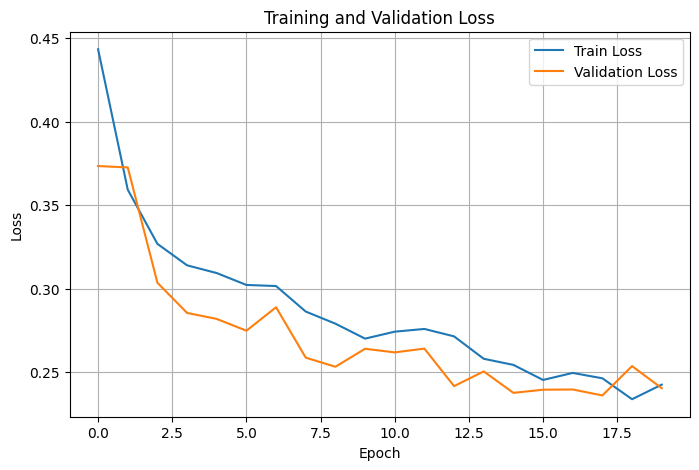

In [39]:
import matplotlib.pyplot as plt

# Plot training and validation loss

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

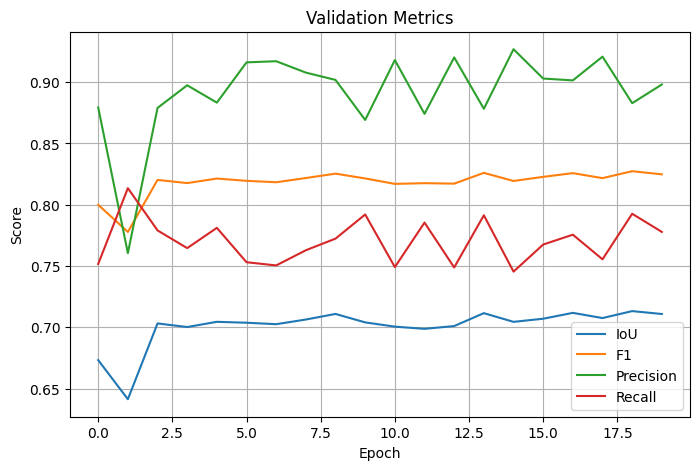

In [40]:
# Plot validation metrics

plt.figure(figsize=(8, 5))
plt.plot(val_ious, label="IoU")
plt.plot(val_f1s, label="F1")
plt.plot(val_precisions, label="Precision")
plt.plot(val_recalls, label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# Evaluate the baseline model on the test set

model.eval()

true_positive = 0
false_positive = 0
false_negative = 0

test_loss = 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)
        test_loss += loss.item()

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        true_positive += ((predictions == 1) & (masks == 1)).sum().item()
        false_positive += ((predictions == 1) & (masks == 0)).sum().item()
        false_negative += ((predictions == 0) & (masks == 1)).sum().item()

test_loss /= len(test_loader)

iou = true_positive / (
    true_positive + false_positive + false_negative + 1e-8
)

precision = true_positive / (
    true_positive + false_positive + 1e-8
)

recall = true_positive / (
    true_positive + false_negative + 1e-8
)

f1 = 2 * precision * recall / (
    precision + recall + 1e-8
)

print("Baseline Test Results")
print("---------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"IoU: {iou:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

Baseline Test Results
---------------------
Test Loss: 0.1899
IoU: 0.7777
Precision: 0.9269
Recall: 0.8285
F1: 0.8750


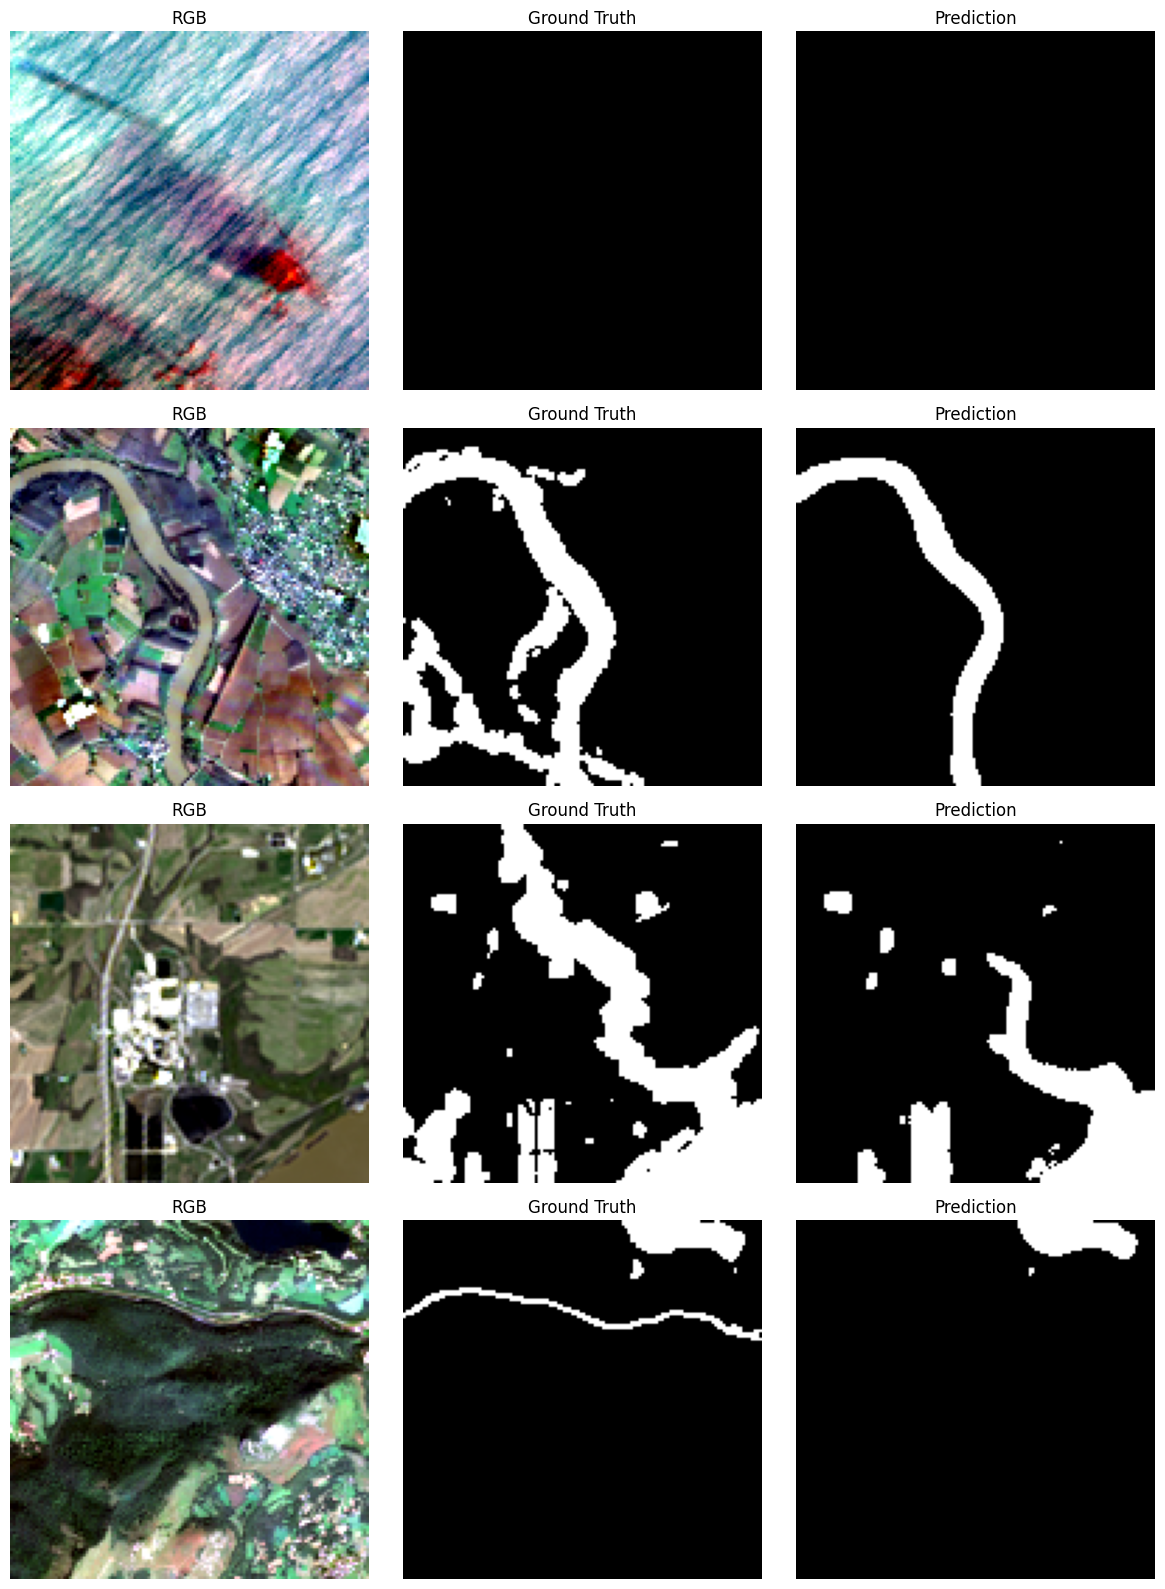

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import torch


def prepare_rgb(image):
    rgb = image[[3, 2, 1]].permute(1, 2, 0).cpu().numpy()

    rgb_min = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    rgb_max = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)

    rgb = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8)
    rgb = np.clip(rgb, 0, 1)

    return rgb


model.eval()

images, masks = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    probabilities = torch.sigmoid(outputs)

predictions = (probabilities >= 0.5).float()

num_samples = 4

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for i in range(num_samples):
    rgb = prepare_rgb(images[i])

    ground_truth = masks[i, 0].numpy()
    prediction = predictions[i, 0].cpu().numpy()

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title("RGB")

    axes[i, 1].imshow(ground_truth, cmap="gray")
    axes[i, 1].set_title("Ground Truth")

    axes[i, 2].imshow(prediction, cmap="gray")
    axes[i, 2].set_title("Prediction")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [43]:
# Calculate MNDWI statistics using the training set only

mndwi_values = []

for image_id in train_ids:
    image_path = os.path.join(images_path, f"{image_id}.tif")
    image = tifffile.imread(image_path).astype(np.float32)

    green = image[:, :, 2]
    swir1 = image[:, :, 5]

    mndwi = (green - swir1) / (green + swir1 + 1e-8)

    mndwi_values.append(mndwi.reshape(-1))

mndwi_values = np.concatenate(mndwi_values)

mndwi_mean = np.mean(mndwi_values)
mndwi_std = np.std(mndwi_values)
mndwi_min = np.min(mndwi_values)
mndwi_max = np.max(mndwi_values)

print("MNDWI Mean:", mndwi_mean)
print("MNDWI Std:", mndwi_std)
print("MNDWI Min:", mndwi_min)
print("MNDWI Max:", mndwi_max)

MNDWI Mean: 18253.225
MNDWI Std: 12741331.0
MNDWI Min: -261.0
MNDWI Max: 13600000000.0


In [44]:
# Inspect the MNDWI denominator for near-zero values

denominator_values = []
near_zero_count = 0
zero_count = 0
total_pixels = 0

for image_id in train_ids:
    image_path = os.path.join(images_path, f"{image_id}.tif")
    image = tifffile.imread(image_path).astype(np.float32)

    green = image[:, :, 2]
    swir1 = image[:, :, 5]

    denominator = green + swir1

    denominator_values.append(denominator.reshape(-1))

    zero_count += np.sum(denominator == 0)
    near_zero_count += np.sum(np.abs(denominator) < 10)
    total_pixels += denominator.size

denominator_values = np.concatenate(denominator_values)

print("Total pixels:", total_pixels)
print("Exact zero denominators:", zero_count)
print("Near-zero denominators (|denominator| < 10):", near_zero_count)
print("Minimum absolute denominator:", np.min(np.abs(denominator_values)))
print("Median absolute denominator:", np.median(np.abs(denominator_values)))

Total pixels: 3506176
Exact zero denominators: 8
Near-zero denominators (|denominator| < 10): 134
Minimum absolute denominator: 0.0
Median absolute denominator: 2663.0


In [45]:
# Calculate robust MNDWI statistics using the training set only

mndwi_values = []

for image_id in train_ids:
    image_path = os.path.join(images_path, f"{image_id}.tif")
    image = tifffile.imread(image_path).astype(np.float32)

    green = image[:, :, 2]
    swir1 = image[:, :, 5]

    denominator = green + swir1

    valid = np.abs(denominator) >= 10

    mndwi = np.zeros_like(green, dtype=np.float32)
    mndwi[valid] = (
        (green[valid] - swir1[valid]) /
        denominator[valid]
    )

    mndwi_values.append(mndwi[valid])

mndwi_values = np.concatenate(mndwi_values)

mndwi_mean = np.mean(mndwi_values)
mndwi_std = np.std(mndwi_values)
mndwi_min = np.min(mndwi_values)
mndwi_max = np.max(mndwi_values)

print("Valid MNDWI pixels:", len(mndwi_values))
print("MNDWI Mean:", mndwi_mean)
print("MNDWI Std:", mndwi_std)
print("MNDWI Min:", mndwi_min)
print("MNDWI Max:", mndwi_max)

Valid MNDWI pixels: 3506042
MNDWI Mean: -0.28313097
MNDWI Std: 0.47830498
MNDWI Min: -32.4
MNDWI Max: 42.384617


In [46]:
# Calculate MNDWI statistics using physically valid values only

mndwi_values = []

for image_id in train_ids:
    image_path = os.path.join(images_path, f"{image_id}.tif")
    image = tifffile.imread(image_path).astype(np.float32)

    green = image[:, :, 2]
    swir1 = image[:, :, 5]

    denominator = green + swir1

    valid = (
        (np.abs(denominator) >= 10) &
        np.isfinite(denominator)
    )

    mndwi = np.zeros_like(green, dtype=np.float32)

    mndwi[valid] = (
        (green[valid] - swir1[valid]) /
        denominator[valid]
    )

    valid_mndwi = mndwi[valid]

    valid_mndwi = valid_mndwi[
        (valid_mndwi >= -1.0) &
        (valid_mndwi <= 1.0)
    ]

    mndwi_values.append(valid_mndwi)

mndwi_values = np.concatenate(mndwi_values)

mndwi_mean = np.mean(mndwi_values)
mndwi_std = np.std(mndwi_values)
mndwi_min = np.min(mndwi_values)
mndwi_max = np.max(mndwi_values)

print("Valid MNDWI pixels:", len(mndwi_values))
print("MNDWI Mean:", mndwi_mean)
print("MNDWI Std:", mndwi_std)
print("MNDWI Min:", mndwi_min)
print("MNDWI Max:", mndwi_max)

Valid MNDWI pixels: 3462701
MNDWI Mean: -0.300402
MNDWI Std: 0.44922647
MNDWI Min: -1.0
MNDWI Max: 1.0


In [47]:
print("Mean variable:", band_means)
print("Std variable:", band_stds)

Mean variable: [ 397.83273   495.26138   823.815     968.2177   2106.018    1960.1437
 1344.0233    100.75856   292.06342   290.80258    34.901108    9.596884]
Std variable: [ 275.94595   333.8354    426.46854   592.6153   1058.7556   1189.7312
  961.94476    47.92592   516.83374   514.28357    20.155993   27.502283]


In [48]:
class MNDWIDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        image_ids,
        images_path,
        labels_path,
        band_means,
        band_stds,
        mndwi_mean,
        mndwi_std,
        augment=False
    ):
        self.image_ids = list(image_ids)
        self.images_path = images_path
        self.labels_path = labels_path
        self.band_means = np.array(band_means, dtype=np.float32)
        self.band_stds = np.array(band_stds, dtype=np.float32)
        self.mndwi_mean = float(mndwi_mean)
        self.mndwi_std = float(mndwi_std)
        self.augment = augment

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        image_path = os.path.join(
            self.images_path,
            f"{image_id}.tif"
        )

        label_path = os.path.join(
            self.labels_path,
            f"{image_id}.png"
        )

        image = tifffile.imread(image_path).astype(np.float32)

        green = image[:, :, 2]
        swir1 = image[:, :, 5]

        denominator = green + swir1

        valid = (
            (np.abs(denominator) >= 10) &
            np.isfinite(denominator)
        )

        mndwi = np.zeros_like(green, dtype=np.float32)

        mndwi[valid] = (
            (green[valid] - swir1[valid]) /
            denominator[valid]
        )

        valid_mndwi = (
            valid &
            (mndwi >= -1.0) &
            (mndwi <= 1.0)
        )

        mndwi[~valid_mndwi] = 0.0

        mndwi = (
            mndwi - self.mndwi_mean
        ) / (self.mndwi_std + 1e-8)

        image = (
            image - self.band_means.reshape(1, 1, 12)
        ) / (
            self.band_stds.reshape(1, 1, 12) + 1e-8
        )

        image = np.concatenate(
            [
                image,
                mndwi[:, :, np.newaxis]
            ],
            axis=2
        )

        image = np.transpose(image, (2, 0, 1))

        mask = np.array(
            Image.open(label_path)
        ).astype(np.float32)

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        if self.augment:

            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            rotation = random.randint(0, 3)

            if rotation > 0:
                image = torch.rot90(
                    image,
                    rotation,
                    dims=[1, 2]
                )

                mask = torch.rot90(
                    mask,
                    rotation,
                    dims=[1, 2]
                )

        mask = (mask > 0).float()

        return image, mask

In [49]:
train_mndwi_dataset = MNDWIDataset(
    train_ids,
    images_path,
    labels_path,
    band_means,
    band_stds,
    mndwi_mean,
    mndwi_std,
    augment=True
)

val_mndwi_dataset = MNDWIDataset(
    val_ids,
    images_path,
    labels_path,
    band_means,
    band_stds,
    mndwi_mean,
    mndwi_std,
    augment=False
)

test_mndwi_dataset = MNDWIDataset(
    test_ids,
    images_path,
    labels_path,
    band_means,
    band_stds,
    mndwi_mean,
    mndwi_std,
    augment=False
)

print("Train samples:", len(train_mndwi_dataset))
print("Validation samples:", len(val_mndwi_dataset))
print("Test samples:", len(test_mndwi_dataset))

Train samples: 214
Validation samples: 46
Test samples: 46


In [50]:
image, mask = train_mndwi_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image dtype:", image.dtype)
print("Mask dtype:", mask.dtype)
print("Image channels:", image.shape[0])
print("Mask values:", torch.unique(mask))

Image shape: torch.Size([13, 128, 128])
Mask shape: torch.Size([1, 128, 128])
Image dtype: torch.float32
Mask dtype: torch.float32
Image channels: 13
Mask values: tensor([0., 1.])


In [51]:
batch_size = 8

train_mndwi_loader = torch.utils.data.DataLoader(
    train_mndwi_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_mndwi_loader = torch.utils.data.DataLoader(
    val_mndwi_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_mndwi_loader = torch.utils.data.DataLoader(
    test_mndwi_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

images, masks = next(iter(train_mndwi_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)
print("Train batches:", len(train_mndwi_loader))
print("Validation batches:", len(val_mndwi_loader))
print("Test batches:", len(test_mndwi_loader))

Images shape: torch.Size([8, 13, 128, 128])
Masks shape: torch.Size([8, 1, 128, 128])
Images dtype: torch.float32
Masks dtype: torch.float32
Train batches: 27
Validation batches: 6
Test batches: 6


In [52]:
model_mndwi = UNet(in_channels=13, out_channels=1).to(device)

total_params = sum(
    p.numel()
    for p in model_mndwi.parameters()
)

print("Model parameters:", total_params)

Model parameters: 31049281


In [53]:
images, masks = next(iter(train_mndwi_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model_mndwi(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([8, 13, 128, 128])
Output shape: torch.Size([8, 1, 128, 128])


In [54]:
criterion_mndwi = nn.BCEWithLogitsLoss()

optimizer_mndwi = torch.optim.Adam(
    model_mndwi.parameters(),
    lr=1e-4
)

print("Loss:", criterion_mndwi)
print("Optimizer:", optimizer_mndwi)

Loss: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [55]:
print(train_model)

NameError: name 'train_model' is not defined

In [56]:
def calculate_metrics_from_counts(tp, fp, fn):
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return iou, precision, recall, f1


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / total_samples


def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    total_tp = 0
    total_fp = 0
    total_fn = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            total_tp += ((predictions == 1) & (masks == 1)).sum().item()
            total_fp += ((predictions == 1) & (masks == 0)).sum().item()
            total_fn += ((predictions == 0) & (masks == 1)).sum().item()

    average_loss = running_loss / total_samples

    iou, precision, recall, f1 = calculate_metrics_from_counts(
        total_tp,
        total_fp,
        total_fn
    )

    return average_loss, iou, precision, recall, f1


def train_model_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=20,
    patience=5
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_iou": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": []
    }

    best_val_iou = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    best_model_state = None

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_iou, val_precision, val_recall, val_f1 = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        history["val_precision"].append(val_precision)
        history["val_recall"].append(val_recall)
        history["val_f1"].append(val_f1)

        epoch_time = time.time() - start_time

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"IoU: {val_iou:.4f} | "
            f"Precision: {val_precision:.4f} | "
            f"Recall: {val_recall:.4f} | "
            f"F1: {val_f1:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            best_epoch = epoch + 1
            epochs_without_improvement = 0

            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}. "
                f"Best epoch: {best_epoch}"
            )
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"Best validation IoU: {best_val_iou:.4f}")
    print(f"Best epoch: {best_epoch}")

    return history

In [57]:
history_mndwi = train_model_with_early_stopping(
    model=model_mndwi,
    train_loader=train_mndwi_loader,
    val_loader=val_mndwi_loader,
    criterion=criterion_mndwi,
    optimizer=optimizer_mndwi,
    device=device,
    num_epochs=20,
    patience=5
)

Epoch 01/20 | Train Loss: 0.5851 | Val Loss: 0.4666 | IoU: 0.6609 | Precision: 0.8236 | Recall: 0.7698 | F1: 0.7958 | Time: 7.1s
Epoch 02/20 | Train Loss: 0.4372 | Val Loss: 0.3773 | IoU: 0.6915 | Precision: 0.9039 | Recall: 0.7464 | F1: 0.8176 | Time: 6.9s
Epoch 03/20 | Train Loss: 0.4095 | Val Loss: 0.3601 | IoU: 0.6874 | Precision: 0.8534 | Recall: 0.7795 | F1: 0.8148 | Time: 6.9s
Epoch 04/20 | Train Loss: 0.3820 | Val Loss: 0.3537 | IoU: 0.6847 | Precision: 0.8136 | Recall: 0.8121 | F1: 0.8129 | Time: 6.8s
Epoch 05/20 | Train Loss: 0.3772 | Val Loss: 0.3540 | IoU: 0.6925 | Precision: 0.8295 | Recall: 0.8074 | F1: 0.8183 | Time: 6.8s
Epoch 06/20 | Train Loss: 0.3660 | Val Loss: 0.3584 | IoU: 0.6588 | Precision: 0.7363 | Recall: 0.8622 | F1: 0.7943 | Time: 6.7s
Epoch 07/20 | Train Loss: 0.3513 | Val Loss: 0.3427 | IoU: 0.6815 | Precision: 0.7708 | Recall: 0.8547 | F1: 0.8106 | Time: 6.6s
Epoch 08/20 | Train Loss: 0.3495 | Val Loss: 0.3404 | IoU: 0.6802 | Precision: 0.7680 | Recall: 0

In [58]:
test_loss_mndwi, test_iou_mndwi, test_precision_mndwi, test_recall_mndwi, test_f1_mndwi = evaluate_model(
    model_mndwi,
    test_mndwi_loader,
    criterion_mndwi,
    device
)

print(f"Test Loss: {test_loss_mndwi:.4f}")
print(f"Test IoU: {test_iou_mndwi:.4f}")
print(f"Test Precision: {test_precision_mndwi:.4f}")
print(f"Test Recall: {test_recall_mndwi:.4f}")
print(f"Test F1: {test_f1_mndwi:.4f}")

Test Loss: 0.2299
Test IoU: 0.7516
Test Precision: 0.8621
Test Recall: 0.8543
Test F1: 0.8582


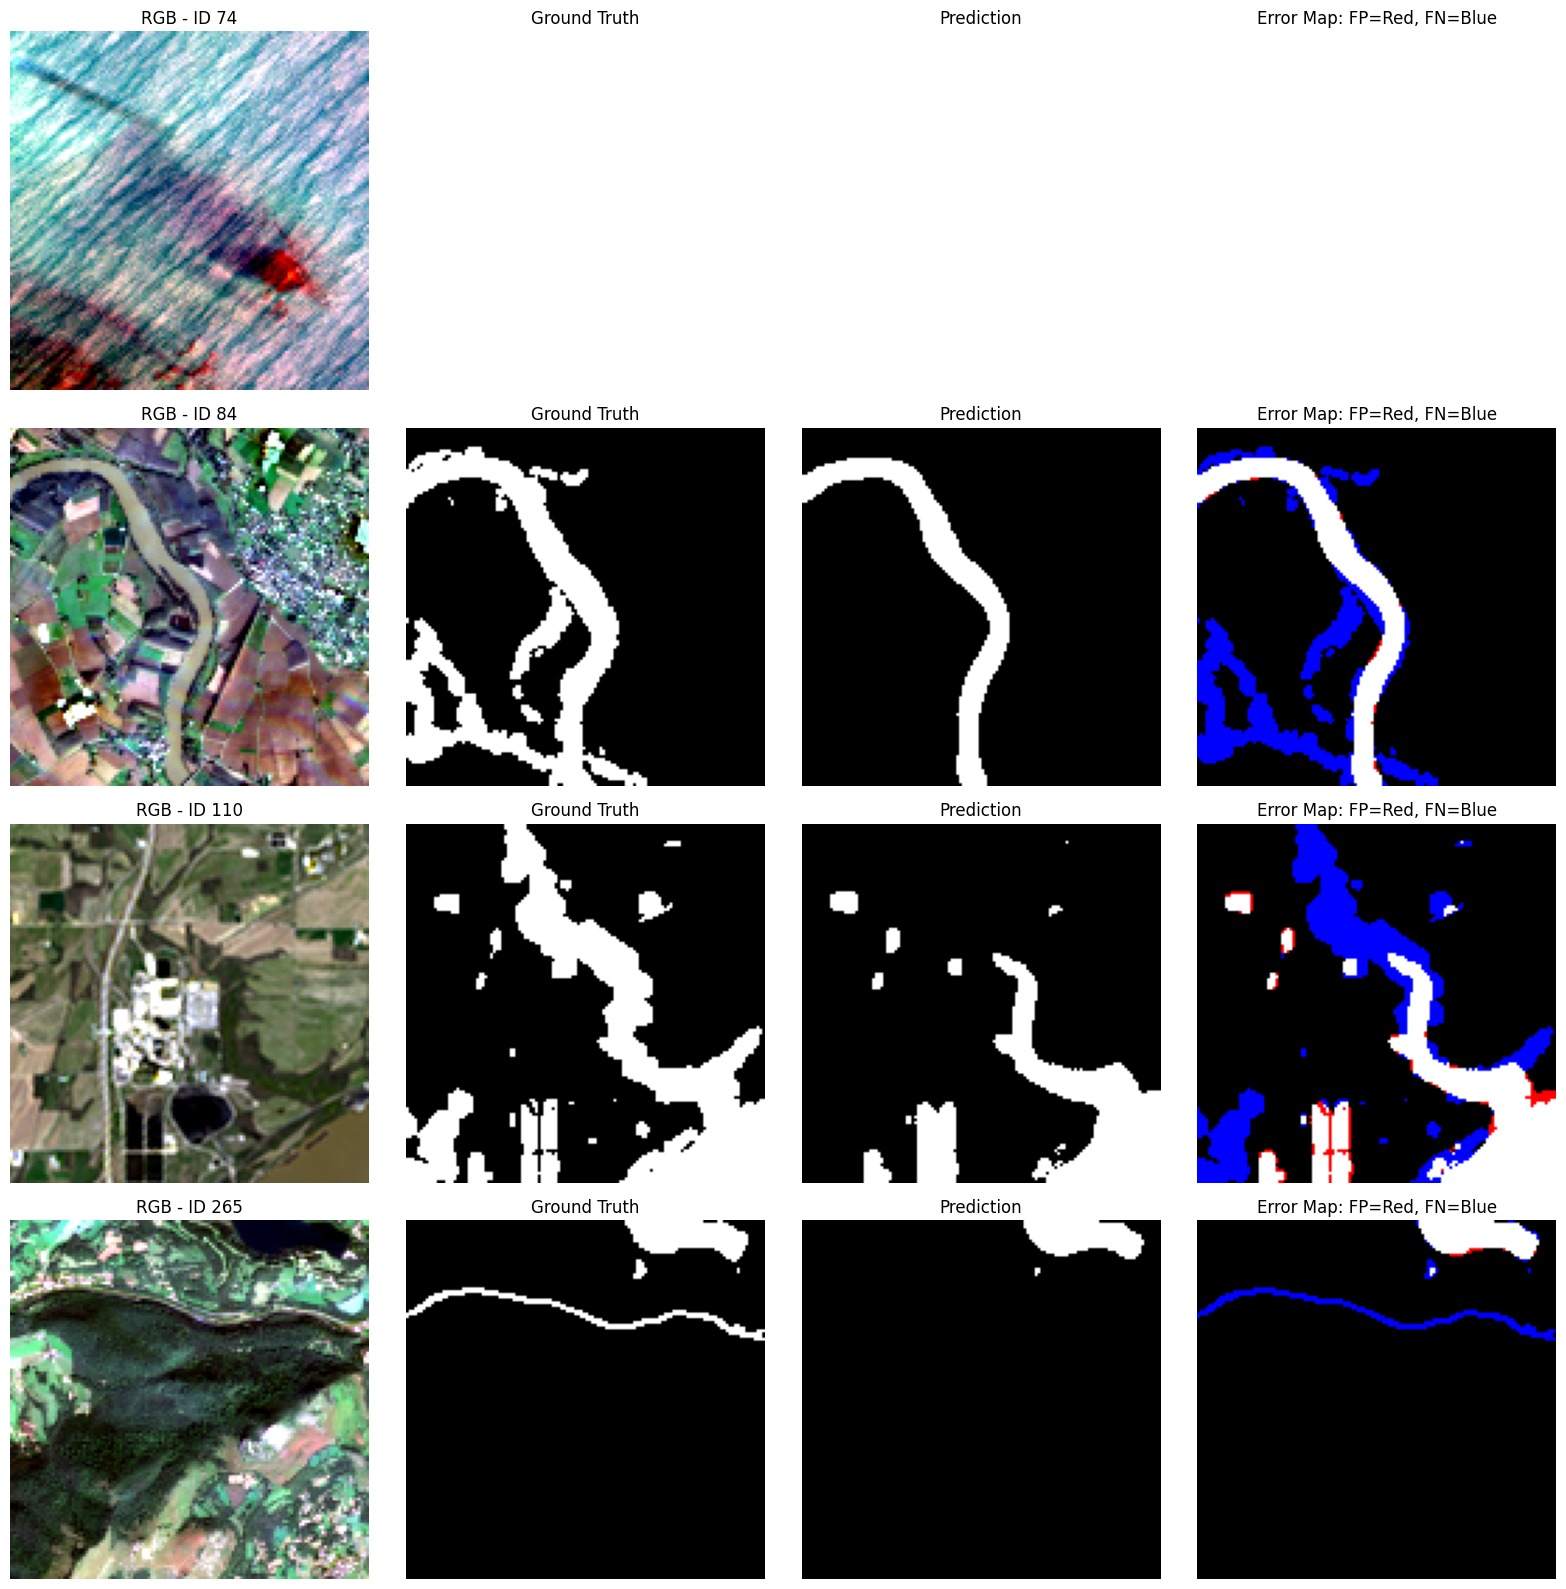

In [59]:
def get_prediction(model, image, device, threshold=0.5):
    model.eval()

    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        logits = model(image_batch)
        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    prediction = (probability >= threshold).astype(np.uint8)

    return probability, prediction


def load_rgb_image(image_id):
    image_path = os.path.join(
        images_path,
        f"{image_id}.tif"
    )

    image = tifffile.imread(image_path).astype(np.float32)

    red = image[:, :, 3]
    green = image[:, :, 2]
    blue = image[:, :, 1]

    rgb = np.stack(
        [red, green, blue],
        axis=-1
    )

    rgb_min = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    rgb_max = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)

    rgb = (rgb - rgb_min) / (
        rgb_max - rgb_min + 1e-8
    )

    rgb = np.clip(rgb, 0, 1)

    return rgb


def calculate_error_map(mask, prediction):
    true_positive = (mask == 1) & (prediction == 1)
    false_positive = (mask == 0) & (prediction == 1)
    false_negative = (mask == 1) & (prediction == 0)

    error_map = np.zeros(
        (*mask.shape, 3),
        dtype=np.float32
    )

    error_map[true_positive] = [1, 1, 1]
    error_map[false_positive] = [1, 0, 0]
    error_map[false_negative] = [0, 0, 1]

    return error_map


baseline_model = model

test_sample_ids = test_ids[:4]

fig, axes = plt.subplots(
    len(test_sample_ids),
    4,
    figsize=(16, 4 * len(test_sample_ids))
)

for row, image_id in enumerate(test_sample_ids):

    image, mask = test_dataset[
        test_ids.index(image_id)
    ]

    rgb = load_rgb_image(image_id)

    probability, prediction = get_prediction(
        baseline_model,
        image,
        device
    )

    ground_truth = mask.squeeze(0).numpy()

    error_map = calculate_error_map(
        ground_truth,
        prediction
    )

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"RGB - ID {image_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(error_map)
    axes[row, 3].set_title(
        "Error Map: FP=Red, FN=Blue"
    )
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

In [60]:
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.contiguous().view(-1)
        targets = targets.contiguous().view(-1)

        intersection = (probabilities * targets).sum()

        dice_score = (
            (2.0 * intersection + 1e-8) /
            (
                probabilities.sum() +
                targets.sum() +
                1e-8
            )
        )

        dice_loss = 1.0 - dice_score

        total_loss = (
            self.bce_weight * bce_loss +
            self.dice_weight * dice_loss
        )

        return total_loss

In [61]:
model_dice = UNet(
    in_channels=12,
    out_channels=1
).to(device)

criterion_dice = DiceBCELoss(
    bce_weight=0.5,
    dice_weight=0.5
)

optimizer_dice = torch.optim.Adam(
    model_dice.parameters(),
    lr=1e-4
)

print("Model parameters:", sum(
    p.numel()
    for p in model_dice.parameters()
))

Model parameters: 31048705


In [62]:
history_dice = train_model_with_early_stopping(
    model=model_dice,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_dice,
    optimizer=optimizer_dice,
    device=device,
    num_epochs=20,
    patience=5
)

Epoch 01/20 | Train Loss: 0.4791 | Val Loss: 0.4293 | IoU: 0.6411 | Precision: 0.7656 | Recall: 0.7976 | F1: 0.7813 | Time: 8.1s
Epoch 02/20 | Train Loss: 0.3908 | Val Loss: 0.3363 | IoU: 0.6606 | Precision: 0.7510 | Recall: 0.8459 | F1: 0.7956 | Time: 6.7s
Epoch 03/20 | Train Loss: 0.3581 | Val Loss: 0.3060 | IoU: 0.6585 | Precision: 0.7643 | Recall: 0.8263 | F1: 0.7941 | Time: 6.8s
Epoch 04/20 | Train Loss: 0.3539 | Val Loss: 0.3288 | IoU: 0.6741 | Precision: 0.7743 | Recall: 0.8390 | F1: 0.8054 | Time: 6.8s
Epoch 05/20 | Train Loss: 0.3215 | Val Loss: 0.2882 | IoU: 0.6884 | Precision: 0.7947 | Recall: 0.8373 | F1: 0.8154 | Time: 6.7s
Epoch 06/20 | Train Loss: 0.3298 | Val Loss: 0.2937 | IoU: 0.6581 | Precision: 0.7311 | Recall: 0.8682 | F1: 0.7938 | Time: 6.7s
Epoch 07/20 | Train Loss: 0.3364 | Val Loss: 0.2944 | IoU: 0.6607 | Precision: 0.7262 | Recall: 0.8799 | F1: 0.7957 | Time: 6.7s
Epoch 08/20 | Train Loss: 0.3157 | Val Loss: 0.2690 | IoU: 0.6946 | Precision: 0.8097 | Recall: 0

In [63]:
test_loss_dice, test_iou_dice, test_precision_dice, test_recall_dice, test_f1_dice = evaluate_model(
    model_dice,
    test_loader,
    criterion_dice,
    device
)

print(f"Test Loss: {test_loss_dice:.4f}")
print(f"Test IoU: {test_iou_dice:.4f}")
print(f"Test Precision: {test_precision_dice:.4f}")
print(f"Test Recall: {test_recall_dice:.4f}")
print(f"Test F1: {test_f1_dice:.4f}")

Test Loss: 0.2014
Test IoU: 0.7756
Test Precision: 0.9154
Test Recall: 0.8355
Test F1: 0.8736


In [64]:
def evaluate_at_threshold(model, loader, device, threshold):
    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= threshold
            ).float()

            total_tp += (
                (predictions == 1) &
                (masks == 1)
            ).sum().item()

            total_fp += (
                (predictions == 1) &
                (masks == 0)
            ).sum().item()

            total_fn += (
                (predictions == 0) &
                (masks == 1)
            ).sum().item()

    iou, precision, recall, f1 = calculate_metrics_from_counts(
        total_tp,
        total_fp,
        total_fn
    )

    return iou, precision, recall, f1


thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    iou, precision, recall, f1 = evaluate_at_threshold(
        baseline_model,
        val_loader,
        device,
        threshold
    )

    threshold_results.append({
        "Threshold": threshold,
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(threshold_results_df.to_string(index=False))

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["IoU"].idxmax()
]

print("\nBest threshold:")
print(best_threshold_row)

 Threshold      IoU  Precision   Recall       F1
      0.30 0.649331   0.676490 0.941771 0.787387
      0.35 0.672739   0.714015 0.920870 0.804356
      0.40 0.689857   0.750546 0.895085 0.816468
      0.45 0.709411   0.808483 0.852707 0.830006
      0.50 0.708369   0.892565 0.774397 0.829293
      0.55 0.700103   0.920780 0.744976 0.823601
      0.60 0.691345   0.938289 0.724278 0.817509
      0.65 0.680426   0.951800 0.704709 0.809826
      0.70 0.667670   0.963425 0.685033 0.800722

Best threshold:
Threshold    0.450000
IoU          0.709411
Precision    0.808483
Recall       0.852707
F1           0.830006
Name: 3, dtype: float64


In [65]:
test_iou_045, test_precision_045, test_recall_045, test_f1_045 = evaluate_at_threshold(
    baseline_model,
    test_loader,
    device,
    threshold=0.45
)

print(f"Test IoU: {test_iou_045:.4f}")
print(f"Test Precision: {test_precision_045:.4f}")
print(f"Test Recall: {test_recall_045:.4f}")
print(f"Test F1: {test_f1_045:.4f}")

Test IoU: 0.7629
Test Precision: 0.8634
Test Recall: 0.8676
Test F1: 0.8655


In [66]:
baseline_val_loss, baseline_val_iou, baseline_val_precision, baseline_val_recall, baseline_val_f1 = evaluate_model(
    baseline_model,
    val_loader,
    criterion,
    device
)

threshold_050_results = evaluate_at_threshold(
    baseline_model,
    val_loader,
    device,
    threshold=0.50
)

print("evaluate_model:")
print(f"IoU: {baseline_val_iou:.6f}")
print(f"Precision: {baseline_val_precision:.6f}")
print(f"Recall: {baseline_val_recall:.6f}")
print(f"F1: {baseline_val_f1:.6f}")

print("\nevaluate_at_threshold:")
print(f"IoU: {threshold_050_results[0]:.6f}")
print(f"Precision: {threshold_050_results[1]:.6f}")
print(f"Recall: {threshold_050_results[2]:.6f}")
print(f"F1: {threshold_050_results[3]:.6f}")

evaluate_model:
IoU: 0.708369
Precision: 0.892565
Recall: 0.774397
F1: 0.829293

evaluate_at_threshold:
IoU: 0.708369
Precision: 0.892565
Recall: 0.774397
F1: 0.829293


In [67]:
print("Available model variables:")
print("model:", type(model))
print("baseline_model:", type(baseline_model))
print("model_dice:", type(model_dice))
print("model_mndwi:", type(model_mndwi))

Available model variables:
model: <class '__main__.UNet'>
baseline_model: <class '__main__.UNet'>
model_dice: <class '__main__.UNet'>
model_mndwi: <class '__main__.UNet'>


In [68]:
models_to_check = {
    "model": model,
    "baseline_model": baseline_model,
    "model_dice": model_dice,
    "model_mndwi": model_mndwi,
}

for name, current_model in models_to_check.items():
    if name == "model_mndwi":
        current_loader = val_mndwi_loader
    else:
        current_loader = val_loader

    val_loss, val_iou, val_precision, val_recall, val_f1 = evaluate_model(
        current_model,
        current_loader,
        criterion if name != "model_dice" else criterion_dice,
        device
    )

    print(f"\n{name}")
    print(f"Loss:      {val_loss:.4f}")
    print(f"IoU:       {val_iou:.4f}")
    print(f"Precision: {val_precision:.4f}")
    print(f"Recall:    {val_recall:.4f}")
    print(f"F1:        {val_f1:.4f}")


model
Loss:      0.2519
IoU:       0.7084
Precision: 0.8926
Recall:    0.7744
F1:        0.8293

baseline_model
Loss:      0.2519
IoU:       0.7084
Precision: 0.8926
Recall:    0.7744
F1:        0.8293

model_dice
Loss:      0.2296
IoU:       0.7201
Precision: 0.8683
Recall:    0.8083
F1:        0.8373

model_mndwi
Loss:      0.2693
IoU:       0.7177
Precision: 0.8313
Recall:    0.8401
F1:        0.8357


In [69]:
print("history:", "history" in globals())
print("history_baseline:", "history_baseline" in globals())
print("best_model_state:", "best_model_state" in globals())
print("best_baseline_model:", "best_baseline_model" in globals())

history: False
history_baseline: False
best_model_state: True
best_baseline_model: False


In [70]:
best_baseline_model = UNet(in_channels=12, out_channels=1).to(device)

best_baseline_model.load_state_dict(best_model_state)

print("Best baseline model restored successfully.")

Best baseline model restored successfully.


In [71]:
val_loss, val_iou, val_precision, val_recall, val_f1 = evaluate_model(
    best_baseline_model,
    val_loader,
    criterion,
    device
)

print("Best Baseline - Validation")
print(f"Loss:      {val_loss:.4f}")
print(f"IoU:       {val_iou:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1:        {val_f1:.4f}")

Best Baseline - Validation
Loss:      0.2519
IoU:       0.7084
Precision: 0.8926
Recall:    0.7744
F1:        0.8293


In [72]:
baseline_clean = UNet(in_channels=12, out_channels=1).to(device)

baseline_optimizer = torch.optim.Adam(
    baseline_clean.parameters(),
    lr=1e-4
)

baseline_criterion = nn.BCEWithLogitsLoss()

print(f"Parameters: {sum(p.numel() for p in baseline_clean.parameters()):,}")

Parameters: 31,048,705


In [73]:
import copy

num_epochs = 20
patience = 5

best_val_iou = -1.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0

baseline_history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

for epoch in range(num_epochs):

    # Training
    baseline_clean.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        baseline_optimizer.zero_grad()

        logits = baseline_clean(images)
        loss = baseline_criterion(logits, masks)

        loss.backward()
        baseline_optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validation
    val_loss, val_iou, val_precision, val_recall, val_f1 = evaluate_model(
        baseline_clean,
        val_loader,
        baseline_criterion,
        device
    )

    baseline_history["train_loss"].append(train_loss)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_iou"].append(val_iou)
    baseline_history["val_precision"].append(val_precision)
    baseline_history["val_recall"].append(val_recall)
    baseline_history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"IoU: {val_iou:.4f} | "
        f"Precision: {val_precision:.4f} | "
        f"Recall: {val_recall:.4f} | "
        f"F1: {val_f1:.4f}"
    )

    # Save best checkpoint
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_epoch = epoch + 1
        best_state = copy.deepcopy(baseline_clean.state_dict())
        epochs_without_improvement = 0

        print(f"  -> New best checkpoint saved at epoch {best_epoch}")

    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Restore best checkpoint
baseline_clean.load_state_dict(best_state)

# Make a completely independent copy for final experiments
best_baseline_model = copy.deepcopy(baseline_clean)

print("\nBest baseline checkpoint restored.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation IoU: {best_val_iou:.4f}")

Epoch 01/20 | Train Loss: 0.5033 | Val Loss: 0.4346 | IoU: 0.6632 | Precision: 0.8046 | Recall: 0.7906 | F1: 0.7975
  -> New best checkpoint saved at epoch 1
Epoch 02/20 | Train Loss: 0.3661 | Val Loss: 0.3557 | IoU: 0.6853 | Precision: 0.8558 | Recall: 0.7748 | F1: 0.8133
  -> New best checkpoint saved at epoch 2
Epoch 03/20 | Train Loss: 0.3651 | Val Loss: 0.3238 | IoU: 0.6918 | Precision: 0.8673 | Recall: 0.7737 | F1: 0.8179
  -> New best checkpoint saved at epoch 3
Epoch 04/20 | Train Loss: 0.3296 | Val Loss: 0.3021 | IoU: 0.6918 | Precision: 0.8867 | Recall: 0.7589 | F1: 0.8178
Epoch 05/20 | Train Loss: 0.3176 | Val Loss: 0.3175 | IoU: 0.6887 | Precision: 0.8527 | Recall: 0.7817 | F1: 0.8157
Epoch 06/20 | Train Loss: 0.3153 | Val Loss: 0.2972 | IoU: 0.6885 | Precision: 0.8593 | Recall: 0.7759 | F1: 0.8155
Epoch 07/20 | Train Loss: 0.3003 | Val Loss: 0.2829 | IoU: 0.7001 | Precision: 0.8835 | Recall: 0.7713 | F1: 0.8236
  -> New best checkpoint saved at epoch 7
Epoch 08/20 | Train 

In [74]:
test_loss, test_iou, test_precision, test_recall, test_f1 = evaluate_model(
    best_baseline_model,
    test_loader,
    baseline_criterion,
    device
)

print("\nBest Baseline - Test")
print(f"Loss:      {test_loss:.4f}")
print(f"IoU:       {test_iou:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")


Best Baseline - Test
Loss:      0.1900
IoU:       0.7750
Precision: 0.9175
Recall:    0.8330
F1:        0.8732


In [75]:
import numpy as np
import matplotlib.pyplot as plt
import torch

best_baseline_model.eval()

# Collect test predictions
all_results = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = best_baseline_model(images)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        for i in range(images.size(0)):
            all_results.append({
                "image": images[i].cpu(),
                "mask": masks[i].cpu(),
                "prediction": predictions[i].cpu(),
                "probability": probabilities[i].cpu()
            })

print(f"Collected {len(all_results)} test samples.")

Collected 46 test samples.


In [76]:
def calculate_sample_metrics(mask, prediction):
    mask = mask.squeeze().numpy().astype(bool)
    prediction = prediction.squeeze().numpy().astype(bool)

    tp = np.logical_and(mask, prediction).sum()
    fp = np.logical_and(~mask, prediction).sum()
    fn = np.logical_and(mask, ~prediction).sum()

    union = tp + fp + fn
    iou = tp / union if union > 0 else 1.0

    return tp, fp, fn, iou


sample_metrics = []

for idx, result in enumerate(all_results):
    tp, fp, fn, iou = calculate_sample_metrics(
        result["mask"],
        result["prediction"]
    )

    sample_metrics.append({
        "index": idx,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "iou": iou
    })

# Sort by worst IoU
sample_metrics_sorted = sorted(
    sample_metrics,
    key=lambda x: x["iou"]
)

print("Worst test samples:")
for item in sample_metrics_sorted[:10]:
    print(
        f"Index {item['index']:3d} | "
        f"IoU {item['iou']:.4f} | "
        f"FP {item['fp']:5d} | "
        f"FN {item['fn']:5d}"
    )

Worst test samples:
Index   4 | IoU 0.0000 | FP     0 | FN   510
Index   6 | IoU 0.0000 | FP     0 | FN    47
Index  10 | IoU 0.0000 | FP     0 | FN   111
Index  12 | IoU 0.0000 | FP     0 | FN   325
Index  30 | IoU 0.0000 | FP     1 | FN    38
Index  34 | IoU 0.0000 | FP     0 | FN    38
Index  33 | IoU 0.0110 | FP    87 | FN     3
Index   8 | IoU 0.1288 | FP     0 | FN   629
Index  14 | IoU 0.1579 | FP     0 | FN    32
Index  22 | IoU 0.1697 | FP    60 | FN  5333


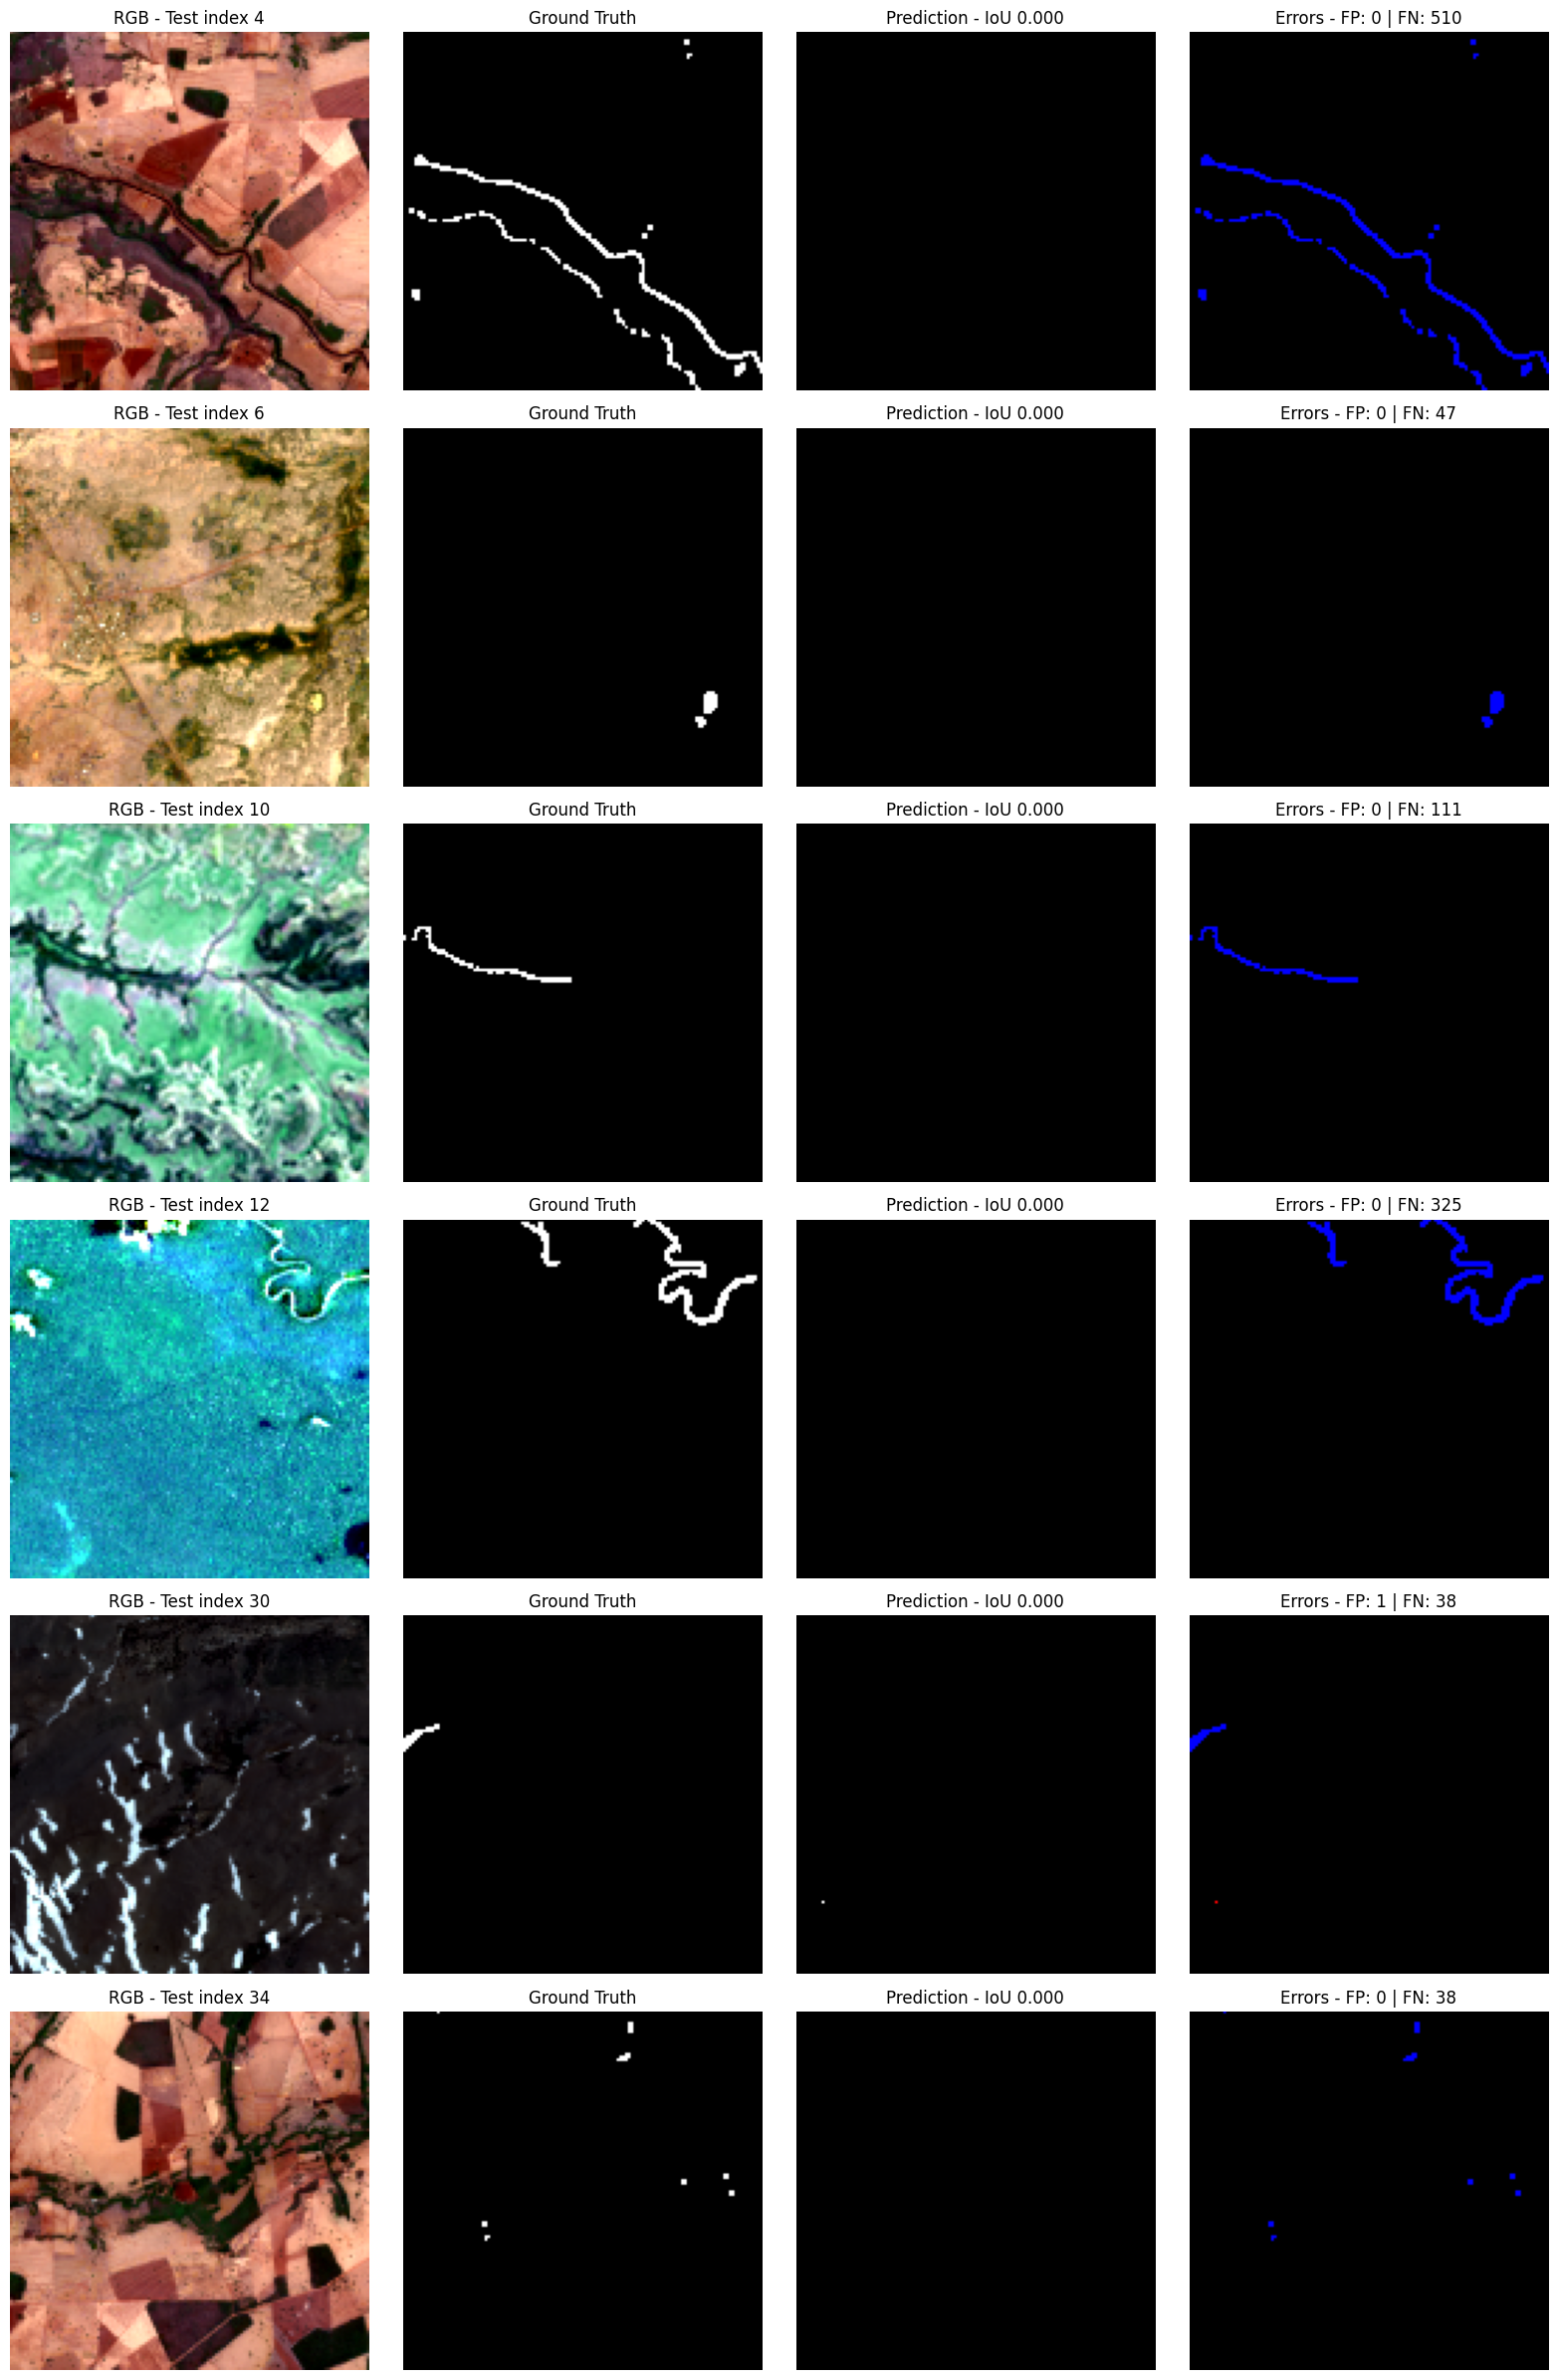

In [77]:
worst_indices = [item["index"] for item in sample_metrics_sorted[:6]]

fig, axes = plt.subplots(
    6, 4,
    figsize=(16, 24)
)

for row, idx in enumerate(worst_indices):
    result = all_results[idx]

    image = result["image"].numpy()
    mask = result["mask"].squeeze().numpy()
    prediction = result["prediction"].squeeze().numpy()

    # Convert normalized channels back to approximate display values
    rgb = image[[3, 2, 1]]

    rgb_min = np.percentile(rgb, 2)
    rgb_max = np.percentile(rgb, 98)

    rgb = np.clip(
        (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8),
        0,
        1
    )

    rgb = np.transpose(rgb, (1, 2, 0))

    # Error map
    error_map = np.zeros(
        (mask.shape[0], mask.shape[1], 3),
        dtype=np.float32
    )

    fp = (prediction == 1) & (mask == 0)
    fn = (prediction == 0) & (mask == 1)

    error_map[fp] = [1, 0, 0]
    error_map[fn] = [0, 0, 1]

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"RGB - Test index {idx}")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Ground Truth")

    axes[row, 2].imshow(prediction, cmap="gray")
    axes[row, 2].set_title(
        f"Prediction - IoU {sample_metrics[idx]['iou']:.3f}"
    )

    axes[row, 3].imshow(error_map)
    axes[row, 3].set_title(
        f"Errors - FP: {sample_metrics[idx]['fp']} | "
        f"FN: {sample_metrics[idx]['fn']}"
    )

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [78]:
def evaluate_at_threshold(model, loader, threshold, device):
    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probabilities = torch.sigmoid(logits)

            predictions = (probabilities >= threshold).float()

            tp = ((predictions == 1) & (masks == 1)).sum().item()
            fp = ((predictions == 1) & (masks == 0)).sum().item()
            fn = ((predictions == 0) & (masks == 1)).sum().item()

            total_tp += tp
            total_fp += fp
            total_fn += fn

    iou = total_tp / (total_tp + total_fp + total_fn + 1e-8)
    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return iou, precision, recall, f1


thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    iou, precision, recall, f1 = evaluate_at_threshold(
        best_baseline_model,
        val_loader,
        threshold,
        device
    )

    threshold_results.append({
        "threshold": threshold,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(
        f"Threshold {threshold:.2f} | "
        f"IoU: {iou:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold 0.30 | IoU: 0.6751 | Precision: 0.7209 | Recall: 0.9141 | F1: 0.8061
Threshold 0.35 | IoU: 0.6901 | Precision: 0.7566 | Recall: 0.8870 | F1: 0.8166
Threshold 0.40 | IoU: 0.7044 | Precision: 0.7969 | Recall: 0.8586 | F1: 0.8266
Threshold 0.45 | IoU: 0.7115 | Precision: 0.8328 | Recall: 0.8300 | F1: 0.8314
Threshold 0.50 | IoU: 0.7131 | Precision: 0.8748 | Recall: 0.7942 | F1: 0.8325
Threshold 0.55 | IoU: 0.6966 | Precision: 0.9249 | Recall: 0.7383 | F1: 0.8211
Threshold 0.60 | IoU: 0.6878 | Precision: 0.9432 | Recall: 0.7175 | F1: 0.8150
Threshold 0.65 | IoU: 0.6796 | Precision: 0.9563 | Recall: 0.7014 | F1: 0.8092
Threshold 0.70 | IoU: 0.6709 | Precision: 0.9658 | Recall: 0.6872 | F1: 0.8030


In [79]:
best_threshold_result = max(
    threshold_results,
    key=lambda x: x["iou"]
)

print("\nBest threshold based on Validation IoU:")
print(f"Threshold: {best_threshold_result['threshold']:.2f}")
print(f"IoU:       {best_threshold_result['iou']:.4f}")
print(f"Precision: {best_threshold_result['precision']:.4f}")
print(f"Recall:    {best_threshold_result['recall']:.4f}")
print(f"F1:        {best_threshold_result['f1']:.4f}")


Best threshold based on Validation IoU:
Threshold: 0.50
IoU:       0.7131
Precision: 0.8748
Recall:    0.7942
F1:        0.8325


In [80]:
id_to_result = {}

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(test_loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model_dice(images)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        for i in range(images.size(0)):
            global_idx = batch_idx * test_loader.batch_size + i

            id_to_result[global_idx] = {
                "prediction": predictions[i].cpu(),
                "probability": probabilities[i].cpu()
            }

print(f"Collected Dice predictions for {len(id_to_result)} test samples.")

Collected Dice predictions for 46 test samples.


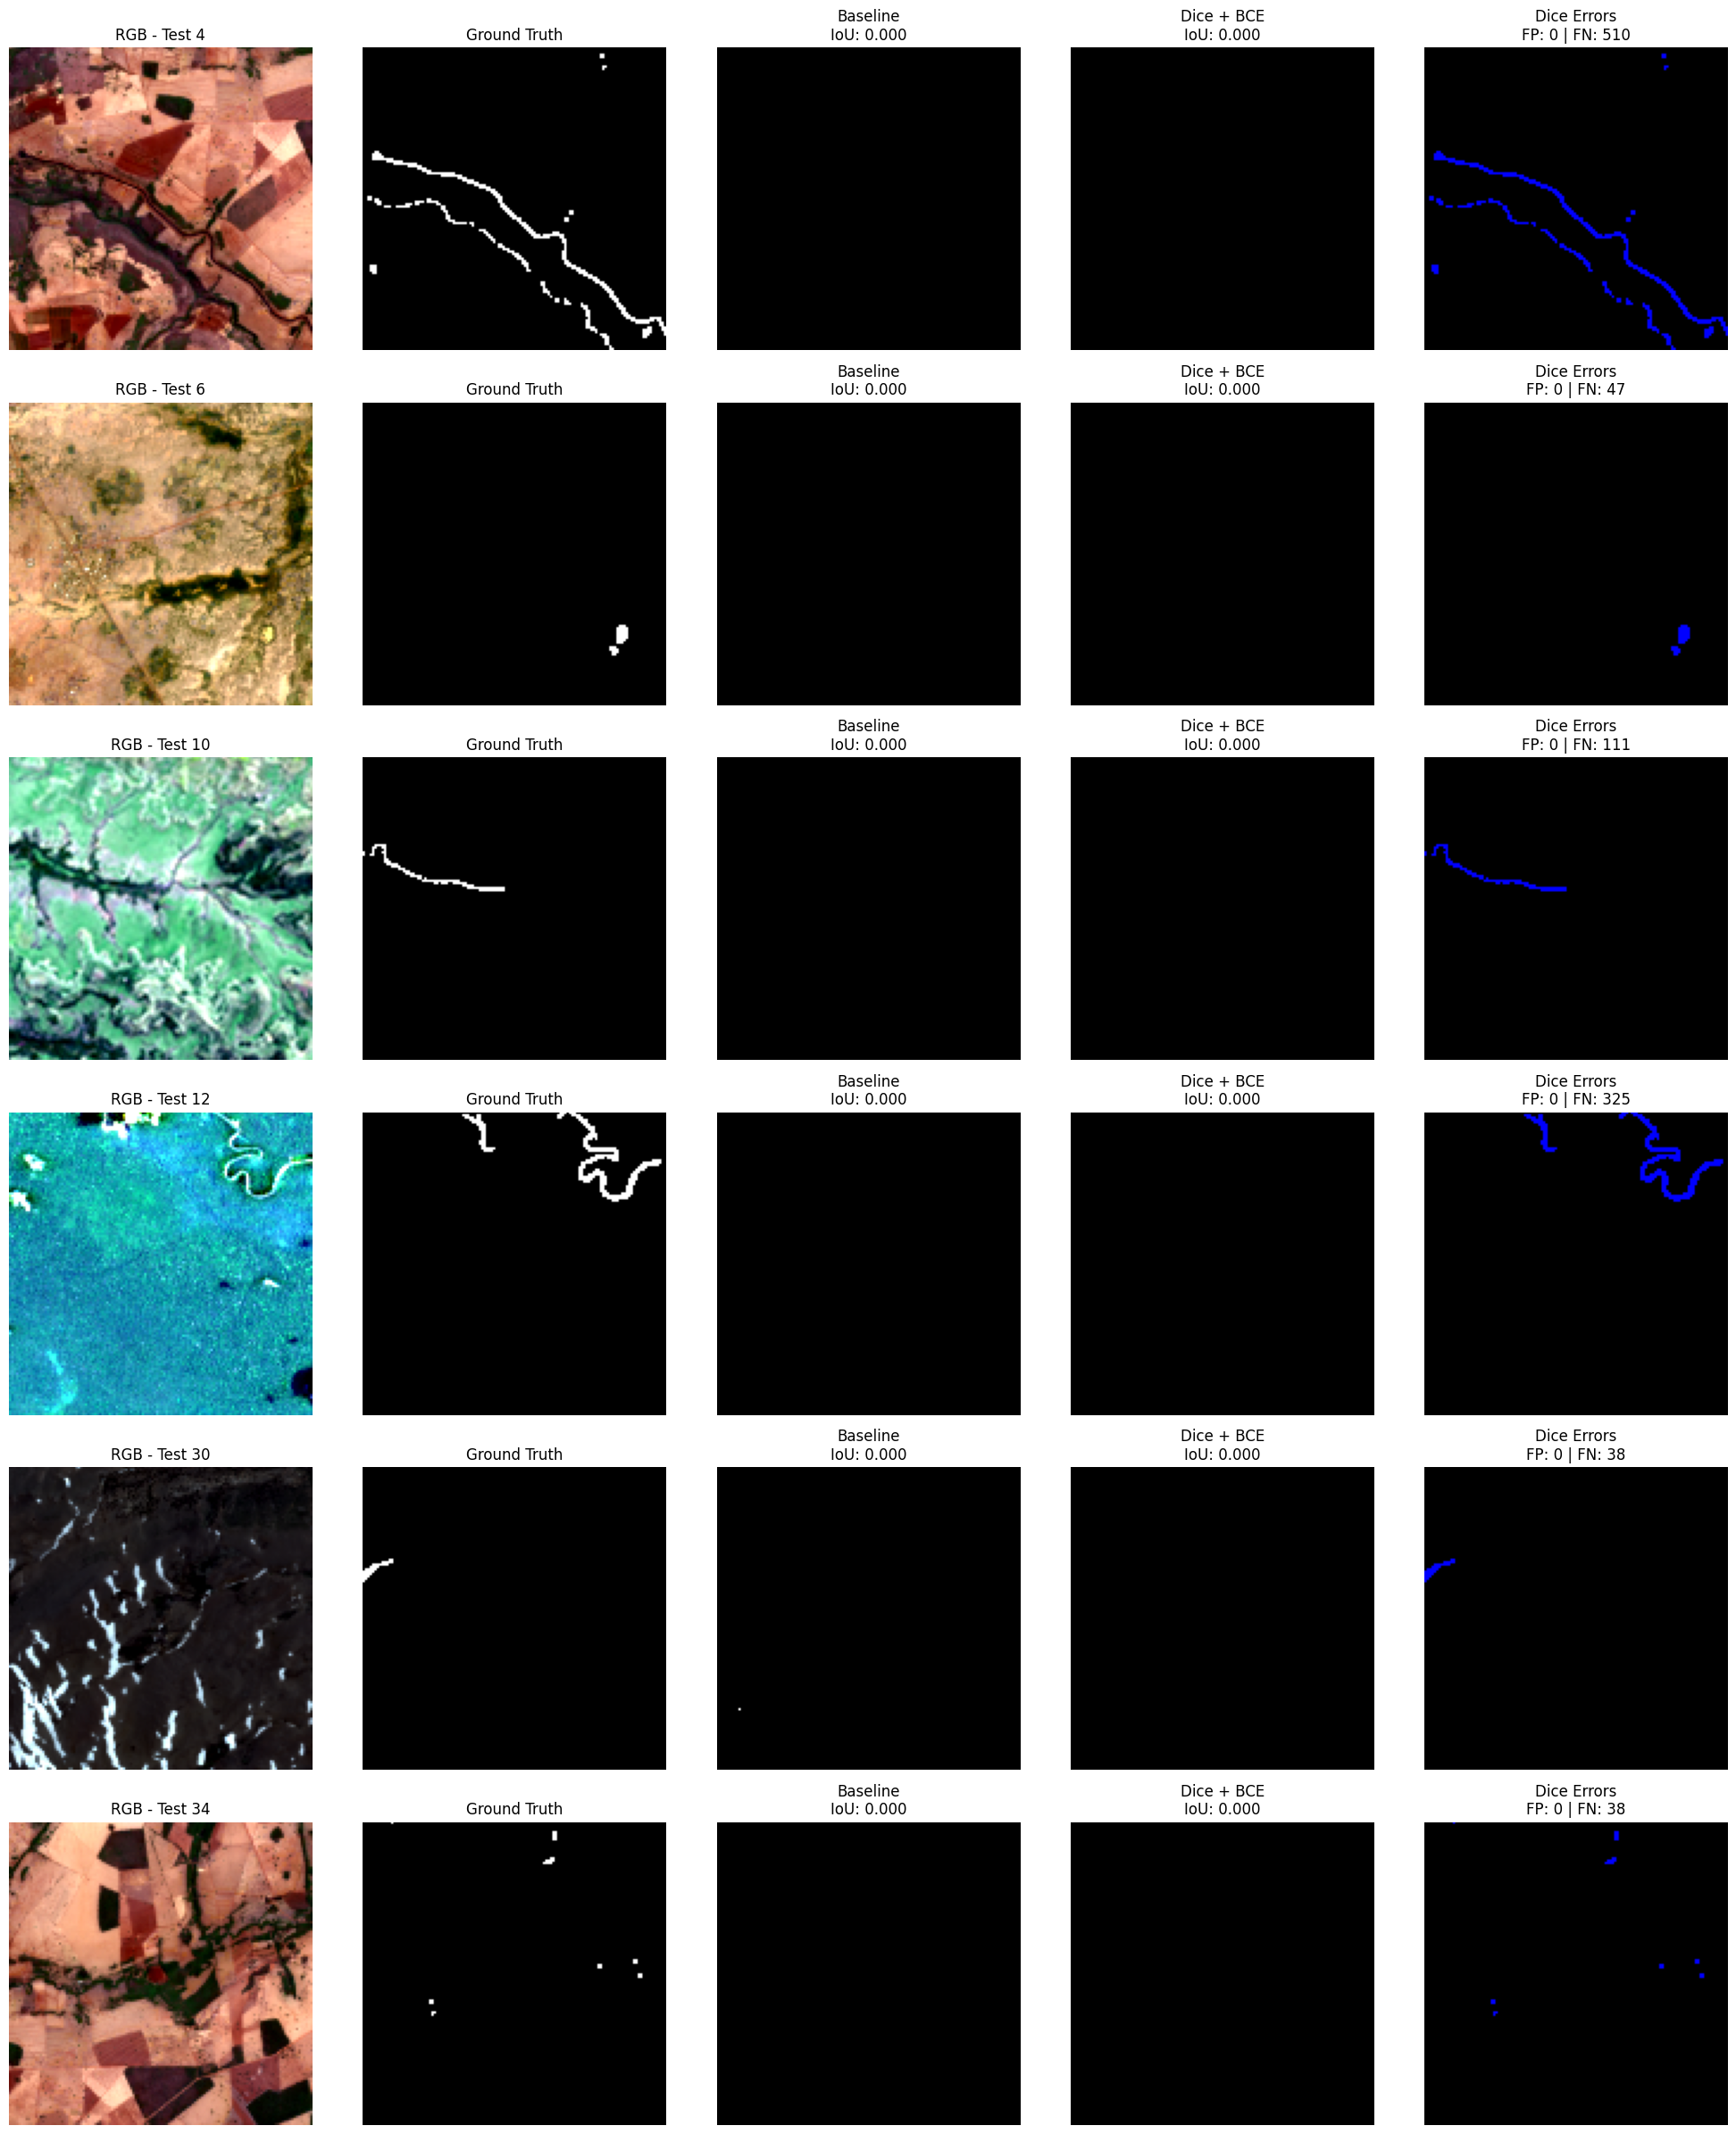

In [81]:
worst_indices = [item["index"] for item in sample_metrics_sorted[:6]]

fig, axes = plt.subplots(
    len(worst_indices), 5,
    figsize=(20, 24)
)

for row, idx in enumerate(worst_indices):

    baseline_result = all_results[idx]
    dice_result = id_to_result[idx]

    image = baseline_result["image"].numpy()
    mask = baseline_result["mask"].squeeze().numpy()

    baseline_prediction = (
        baseline_result["prediction"].squeeze().numpy()
    )

    dice_prediction = (
        dice_result["prediction"].squeeze().numpy()
    )

    # RGB
    rgb = image[[3, 2, 1]]

    rgb_min = np.percentile(rgb, 2)
    rgb_max = np.percentile(rgb, 98)

    rgb = np.clip(
        (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8),
        0,
        1
    )

    rgb = np.transpose(rgb, (1, 2, 0))

    # Baseline error map
    baseline_error = np.zeros(
        (mask.shape[0], mask.shape[1], 3),
        dtype=np.float32
    )

    baseline_fp = (baseline_prediction == 1) & (mask == 0)
    baseline_fn = (baseline_prediction == 0) & (mask == 1)

    baseline_error[baseline_fp] = [1, 0, 0]
    baseline_error[baseline_fn] = [0, 0, 1]

    # Dice error map
    dice_error = np.zeros(
        (mask.shape[0], mask.shape[1], 3),
        dtype=np.float32
    )

    dice_fp = (dice_prediction == 1) & (mask == 0)
    dice_fn = (dice_prediction == 0) & (mask == 1)

    dice_error[dice_fp] = [1, 0, 0]
    dice_error[dice_fn] = [0, 0, 1]

    # Metrics
    _, baseline_fp_count, baseline_fn_count, baseline_iou = (
        calculate_sample_metrics(
            baseline_result["mask"],
            baseline_result["prediction"]
        )
    )

    _, dice_fp_count, dice_fn_count, dice_iou = (
        calculate_sample_metrics(
            baseline_result["mask"],
            dice_result["prediction"]
        )
    )

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"RGB - Test {idx}")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Ground Truth")

    axes[row, 2].imshow(baseline_prediction, cmap="gray")
    axes[row, 2].set_title(
        f"Baseline\nIoU: {baseline_iou:.3f}"
    )

    axes[row, 3].imshow(dice_prediction, cmap="gray")
    axes[row, 3].set_title(
        f"Dice + BCE\nIoU: {dice_iou:.3f}"
    )

    axes[row, 4].imshow(dice_error)
    axes[row, 4].set_title(
        f"Dice Errors\nFP: {dice_fp_count} | FN: {dice_fn_count}"
    )

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [82]:
# Calculate class distribution from the training masks only

total_water = 0
total_non_water = 0

for _, masks in train_loader:
    total_water += (masks == 1).sum().item()
    total_non_water += (masks == 0).sum().item()

pos_weight_value = total_non_water / total_water

print(f"Training water pixels:     {total_water:,}")
print(f"Training non-water pixels: {total_non_water:,}")
print(f"Positive weight:           {pos_weight_value:.4f}")

Training water pixels:     919,523
Training non-water pixels: 2,586,653
Positive weight:           2.8130


In [83]:
class WeightedDiceBCELoss(nn.Module):
    def __init__(self, pos_weight, bce_weight=0.5, dice_weight=0.5):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], device=device)
        )

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probabilities = torch.sigmoid(logits)

        smooth = 1e-6

        intersection = (probabilities * targets).sum()
        dice_score = (
            (2 * intersection + smooth)
            / (probabilities.sum() + targets.sum() + smooth)
        )

        dice_loss = 1 - dice_score

        total_loss = (
            self.bce_weight * bce_loss
            + self.dice_weight * dice_loss
        )

        return total_loss

In [84]:
weighted_model = UNet(
    in_channels=12,
    out_channels=1
).to(device)

weighted_criterion = WeightedDiceBCELoss(
    pos_weight=pos_weight_value
)

weighted_optimizer = torch.optim.Adam(
    weighted_model.parameters(),
    lr=1e-4
)

print(
    f"Parameters: "
    f"{sum(p.numel() for p in weighted_model.parameters()):,}"
)

Parameters: 31,048,705


In [85]:
num_epochs = 20
patience = 5

best_weighted_iou = -1.0
best_weighted_epoch = 0
best_weighted_state = None
epochs_without_improvement = 0

weighted_history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

for epoch in range(num_epochs):

    weighted_model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        weighted_optimizer.zero_grad()

        logits = weighted_model(images)
        loss = weighted_criterion(logits, masks)

        loss.backward()
        weighted_optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    val_loss, val_iou, val_precision, val_recall, val_f1 = evaluate_model(
        weighted_model,
        val_loader,
        weighted_criterion,
        device
    )

    weighted_history["train_loss"].append(train_loss)
    weighted_history["val_loss"].append(val_loss)
    weighted_history["val_iou"].append(val_iou)
    weighted_history["val_precision"].append(val_precision)
    weighted_history["val_recall"].append(val_recall)
    weighted_history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"IoU: {val_iou:.4f} | "
        f"Precision: {val_precision:.4f} | "
        f"Recall: {val_recall:.4f} | "
        f"F1: {val_f1:.4f}"
    )

    if val_iou > best_weighted_iou:
        best_weighted_iou = val_iou
        best_weighted_epoch = epoch + 1

        best_weighted_state = copy.deepcopy(
            weighted_model.state_dict()
        )

        epochs_without_improvement = 0

        print(
            f"  -> New best checkpoint saved "
            f"at epoch {best_weighted_epoch}"
        )

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

weighted_model.load_state_dict(best_weighted_state)

best_weighted_model = copy.deepcopy(weighted_model)

print("\nBest weighted model restored.")
print(f"Best epoch: {best_weighted_epoch}")
print(f"Best validation IoU: {best_weighted_iou:.4f}")

Epoch 01/20 | Train Loss: 0.5841 | Val Loss: 0.4905 | IoU: 0.6353 | Precision: 0.7286 | Recall: 0.8323 | F1: 0.7770
  -> New best checkpoint saved at epoch 1
Epoch 02/20 | Train Loss: 0.4912 | Val Loss: 0.4093 | IoU: 0.6170 | Precision: 0.6605 | Recall: 0.9035 | F1: 0.7631
Epoch 03/20 | Train Loss: 0.4458 | Val Loss: 0.4157 | IoU: 0.5980 | Precision: 0.6311 | Recall: 0.9193 | F1: 0.7484
Epoch 04/20 | Train Loss: 0.4618 | Val Loss: 0.4088 | IoU: 0.6173 | Precision: 0.6511 | Recall: 0.9222 | F1: 0.7633
Epoch 05/20 | Train Loss: 0.4288 | Val Loss: 0.4442 | IoU: 0.5414 | Precision: 0.5562 | Recall: 0.9533 | F1: 0.7025
Epoch 06/20 | Train Loss: 0.4076 | Val Loss: 0.3735 | IoU: 0.6805 | Precision: 0.7426 | Recall: 0.8906 | F1: 0.8099
  -> New best checkpoint saved at epoch 6
Epoch 07/20 | Train Loss: 0.4108 | Val Loss: 0.3984 | IoU: 0.5894 | Precision: 0.6203 | Recall: 0.9219 | F1: 0.7416
Epoch 08/20 | Train Loss: 0.4280 | Val Loss: 0.4048 | IoU: 0.6125 | Precision: 0.6408 | Recall: 0.9328 |

## Experiment Comparison


In [86]:
import pandas as pd

experiment_results = pd.DataFrame([
    {
        "Experiment": "Baseline U-Net",
        "Input": "12 bands",
        "Val IoU": 0.7133,
        "Test IoU": 0.7750,
        "Test Precision": 0.9175,
        "Test Recall": 0.8330,
        "Test F1": 0.8732
    },
    {
        "Experiment": "MNDWI + U-Net",
        "Input": "12 bands + MNDWI",
        "Val IoU": 0.7177,
        "Test IoU": 0.7516,
        "Test Precision": 0.8621,
        "Test Recall": 0.8543,
        "Test F1": 0.8582
    },
    {
        "Experiment": "Dice + BCE",
        "Input": "12 bands",
        "Val IoU": 0.7201,
        "Test IoU": 0.7756,
        "Test Precision": 0.9154,
        "Test Recall": 0.8355,
        "Test F1": 0.8736
    },
    {
        "Experiment": "Weighted BCE + Dice",
        "Input": "12 bands",
        "Val IoU": 0.6805,
        "Test IoU": None,
        "Test Precision": None,
        "Test Recall": None,
        "Test F1": None
    }
])

experiment_results

,Experiment,Input,Val IoU,Test IoU,Test Precision,Test Recall,Test F1
0,Baseline U-Net,12 bands,0.7133,0.7750,0.9175,0.8330,0.8732
1,MNDWI + U-Net,12 bands + MNDWI,0.7177,0.7516,0.8621,0.8543,0.8582
2,Dice + BCE,12 bands,0.7201,0.7756,0.9154,0.8355,0.8736
3,Weighted BCE + Dice,12 bands,0.6805,NaN,NaN,NaN,NaN


In [87]:
experiment_results.to_csv(
    "experiment_results.csv",
    index=False
)

# Final Results

The experiments evaluated the effect of multispectral feature engineering and different loss functions on water segmentation.

| Experiment | Input | Validation IoU | Test IoU | Test Precision | Test Recall | Test F1 |
|---|---|---:|---:|---:|---:|---:|
| Baseline U-Net | 12 bands | 0.7133 | 0.7750 | 0.9175 | 0.8330 | 0.8732 |
| MNDWI + U-Net | 12 bands + MNDWI | 0.7177 | 0.7516 | 0.8621 | 0.8543 | 0.8582 |
| Dice + BCE | 12 bands | 0.7201 | 0.7756 | 0.9154 | 0.8355 | 0.8736 |
| Weighted BCE + Dice | 12 bands | 0.6805 | Not evaluated | Not evaluated | Not evaluated | Not evaluated |

The baseline U-Net achieved a test IoU of 0.7750 and a test F1-score of 0.8732. The MNDWI experiment improved validation IoU but did not improve test performance. Dice + BCE produced very similar test performance to the baseline. The weighted BCE + Dice experiment increased recall during training but reduced validation IoU because of increased false-positive predictions.


## Conclusion

This project developed a U-Net model from scratch for binary water segmentation using 12-channel multispectral and auxiliary remote-sensing data.

The baseline model achieved a test IoU of 0.7750 and a test F1-score of 0.8732. The experiments showed that adding MNDWI as an additional feature improved validation performance but did not improve performance on the held-out test set. The Dice + BCE loss produced performance very close to the baseline, while the weighted BCE + Dice experiment increased recall but reduced IoU because of increased false-positive predictions.

Error analysis showed that the main remaining difficulty is detecting thin, small, and low-area water regions. Threshold analysis also showed that the default threshold of 0.50 was appropriate based on validation IoU.

Overall, the experiments demonstrate that the 12-channel U-Net provides a strong baseline for this dataset, while the tested feature-engineering and loss-function modifications did not provide a consistent improvement on the test set.
